In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                              confusion_matrix, RocCurveDisplay, precision_recall_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

PROJECT_PATH = "/content/drive/MyDrive/BRFSS_Project"
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.3f}'.format)

print("Setup complete!")

Mounted at /content/drive
Setup complete!


In [3]:
print("=" * 60)
print("LOADING JUAN'S OUTPUT FILES")
print("=" * 60)

try:
    df_7yr  = pd.read_csv(f"{PROJECT_PATH}/clean_data/brfss_7yr_slim_clean.csv")
    print(f"✓ brfss_7yr_slim_clean.csv      — {df_7yr.shape[0]:,} rows × {df_7yr.shape[1]} cols")
except FileNotFoundError:
    print("✗ brfss_7yr_slim_clean.csv NOT FOUND ")

try:
    df_agg  = pd.read_csv(f"{PROJECT_PATH}/clean_data/brfss_state_year_agg_FINAL.csv")
    print(f"✓ brfss_state_year_agg_FINAL.csv — {df_agg.shape[0]:,} rows × {df_agg.shape[1]} cols")
except FileNotFoundError:
    print("✗ brfss_state_year_agg_FINAL.csv NOT FOUND ")

try:
    df_2024 = pd.read_csv(f"{PROJECT_PATH}/clean_data/brfss_2024_individual.csv")
    print(f"✓ brfss_2024_individual.csv      — {df_2024.shape[0]:,} rows × {df_2024.shape[1]} cols")
except FileNotFoundError:
    print("✗ brfss_2024_individual.csv NOT FOUND ")

LOADING JUAN'S OUTPUT FILES
✓ brfss_7yr_slim_clean.csv      — 2,595,044 rows × 119 cols
✓ brfss_state_year_agg_FINAL.csv — 317 rows × 31 cols
✓ brfss_2024_individual.csv      — 457,670 rows × 119 cols


In [4]:
print("\n" + "=" * 60)
print("CHECK 1: YEAR COVERAGE")
print("=" * 60)

year_counts = df_7yr['SURVEY_YEAR'].value_counts().sort_index()
print("\nRows per year in 7yr file:")
print(year_counts.to_string())

# Expected: ~370K-460K per year
expected_years = [2019, 2020, 2021, 2022, 2023, 2024]
for yr in expected_years:
    if yr not in year_counts.index:
        print(f"  ✗ MISSING YEAR: {yr} — Juan needs to check his download")
    else:
        n = year_counts[yr]
        if n < 300000:
            print(f"  ⚠ {yr}: {n:,} rows — seems low, expected 370K+")
        else:
            print(f"  ✓ {yr}: {n:,} rows — OK")

# 2024 file should match
print(f"\n2024 standalone file: {len(df_2024):,} rows")
if 2024 in year_counts.index:
    match = len(df_2024) == year_counts[2024]
    print(f"  Matches 7yr file: {'✓ YES' if match else '✗ NO — investigate'}")




CHECK 1: YEAR COVERAGE

Rows per year in 7yr file:
SURVEY_YEAR
2019    418268
2020    401958
2021    438693
2022    445132
2023    433323
2024    457670
  ✓ 2019: 418,268 rows — OK
  ✓ 2020: 401,958 rows — OK
  ✓ 2021: 438,693 rows — OK
  ✓ 2022: 445,132 rows — OK
  ✓ 2023: 433,323 rows — OK
  ✓ 2024: 457,670 rows — OK

2024 standalone file: 457,670 rows
  Matches 7yr file: ✓ YES


In [ ]:
print("\n" + "=" * 60)
print("CHECK 2: STATE COVERAGE")
print("=" * 60)

n_states = df_7yr['_STATE'].nunique()
print(f"Unique states in 7yr file: {n_states} (expected 50-56 incl. territories)")
if n_states < 50:
    print(f"  ✗ PROBLEM: fewer than 50 states ")
else:
    print(f"  ✓ OK")

print(f"\nState-year aggregate shape: {df_agg.shape}")
expected_rows = n_states * 6  # 6 years
print(f"  Expected ~{expected_rows} rows ({n_states} states × 6 years)")
if abs(df_agg.shape[0] - expected_rows) > 10:
    print(f"  ⚠ Row count off — check for duplicate state-year combinations")
else:
    print(f"  ✓ OK")

# Check for duplicate state-year pairs in aggregate
dupes = df_agg.groupby(['_STATE','SURVEY_YEAR']).size()
if (dupes > 1).any():
    print(f"\n  ✗ DUPLICATE STATE-YEAR PAIRS FOUND:")
    print(dupes[dupes > 1])
else:
    print(f"  ✓ No duplicate state-year pairs")



CHECK 2: STATE COVERAGE
Unique states in 7yr file: 54 (expected 50-56 incl. territories)
  ✓ OK

State-year aggregate shape: (317, 31)
  Expected ~324 rows (54 states × 6 years)
  ✓ OK
  ✓ No duplicate state-year pairs


In [5]:
print("\n" + "=" * 60)
print("CHECK 3: TARGET VARIABLE (MENTHLTH / FREQUENT_DISTRESS)")
print("=" * 60)

# Check in 2024 file
if 'MENTHLTH' in df_2024.columns:
    raw = df_2024['MENTHLTH']
    print(f"\nMENTHLTH in 2024 file:")
    print(f"  Missing  : {raw.isna().sum():,} ({raw.isna().mean()*100:.2f}%)")
    print(f"  Min/Max  : {raw.min()} / {raw.max()}")
    print(f"  88 values: {(raw == 88).sum():,}  ← should be 0 (should be recoded to 0)")
    print(f"  77 values: {(raw == 77).sum():,}  ← should be 0 (should be NaN)")
    print(f"  99 values: {(raw == 99).sum():,}  ← should be 0 (should be NaN)")
    print(f"  0 values : {(raw == 0).sum():,}   ← 88 recoded correctly to 0")

if 'FREQUENT_DISTRESS' in df_2024.columns:
    fd = df_2024['FREQUENT_DISTRESS']
    print(f"\nFREQUENT_DISTRESS in 2024 file:")
    print(f"  Class 0 (no distress) : {(fd==0).sum():,} ({(fd==0).mean()*100:.1f}%)")
    print(f"  Class 1 (distress)    : {(fd==1).sum():,} ({(fd==1).mean()*100:.1f}%)")
    print(f"  NaN                   : {fd.isna().sum():,}")
    prevalence = (fd==1).mean()
    if 0.10 <= prevalence <= 0.20:
        print(f"  ✓ Prevalence {prevalence:.1%} — in expected range (10-20%)")
    else:
        print(f"  ⚠ Prevalence {prevalence:.1%} — outside expected range, check recode")
else:
    print("\n  ⚠ FREQUENT_DISTRESS column not found — ")
    print("     will create it  in Phase 2 (this is OK)")


# ── CCHECK 4 — ACE variable integrity ─────────────────────────────────
print("\n" + "=" * 60)
print("CHECK 4: ACE VARIABLES")
print("=" * 60)

ace_cols = ['ACEDEPRS','ACEDRINK','ACEDRUGS','ACEPRISN','ACEDIVRC',
            'ACEPUNCH','ACEHURT1','ACESWEAR','ACETOUCH','ACETTHEM','ACEHVSEX']
ace_protective = ['ACEADSAF','ACEADNED']

print("\nACE adversity variables in 2024 file:")
for col in ace_cols:
    if col in df_2024.columns:
        vals = df_2024[col].value_counts(dropna=False).to_dict()
        missing_pct = df_2024[col].isna().mean() * 100
        unique_vals = sorted(df_2024[col].dropna().unique())
        # Should be 0/1 after recoding, or 1/2 if not yet recoded
        if set(unique_vals).issubset({0, 1}):
            status = "✓ recoded (0/1)"
        elif set(unique_vals).issubset({1, 2}):
            status = "⚠ NOT recoded yet (still 1/2)"
        elif set(unique_vals).issubset({1, 2, 3}):
            status = "⚠ NOT recoded (freq codes 1/2/3)"
        else:
            status = f"? unexpected values: {unique_vals[:5]}"
        print(f"  {col:<12}: {missing_pct:.1f}% missing | {status}")
    else:
        print(f"  {col:<12}: ✗ COLUMN MISSING")

print("\nACE protective variables:")
for col in ace_protective:
    if col in df_2024.columns:
        missing_pct = df_2024[col].isna().mean() * 100
        print(f"  {col:<12}: {missing_pct:.1f}% missing | ✓ present")
    else:
        print(f"  {col:<12}: ✗ MISSING — should be in 2024 data")

# ACE_SCORE check
if 'ACE_SCORE' in df_2024.columns:
    print(f"\n  ACE_SCORE: mean={df_2024['ACE_SCORE'].mean():.2f}, "
          f"max={df_2024['ACE_SCORE'].max()}")
    print(f"  ✓ Composite ACE score present")
else:
    print(f"\n  ⚠ ACE_SCORE not computed yet — will create in Phase 2")


CHECK 3: TARGET VARIABLE (MENTHLTH / FREQUENT_DISTRESS)

MENTHLTH in 2024 file:
  Missing  : 8,156 (1.78%)
  Min/Max  : 0.0 / 30.0
  88 values: 0  ← should be 0 (should be recoded to 0)
  77 values: 0  ← should be 0 (should be NaN)
  99 values: 0  ← should be 0 (should be NaN)
  0 values : 269,909   ← 88 recoded correctly to 0

FREQUENT_DISTRESS in 2024 file:
  Class 0 (no distress) : 387,199 (84.6%)
  Class 1 (distress)    : 62,315 (13.6%)
  NaN                   : 8,156
  ✓ Prevalence 13.6% — in expected range (10-20%)

CHECK 4: ACE VARIABLES

ACE adversity variables in 2024 file:
  ACEDEPRS    : 91.5% missing | ✓ recoded (0/1)
  ACEDRINK    : 91.5% missing | ✓ recoded (0/1)
  ACEDRUGS    : 91.5% missing | ✓ recoded (0/1)
  ACEPRISN    : 91.5% missing | ✓ recoded (0/1)
  ACEDIVRC    : 91.7% missing | ✓ recoded (0/1)
  ACEPUNCH    : 91.7% missing | ✓ recoded (0/1)
  ACEHURT1    : 91.6% missing | ✓ recoded (0/1)
  ACESWEAR    : 91.6% missing | ✓ recoded (0/1)
  ACETOUCH    : 91.6% mis

In [ ]:
print("\n" + "=" * 60)
print("CHECK 5: SDOH VARIABLES (new in 2022-2024)")
print("=" * 60)

sdoh_vars = {
    'SDLONELY': 'Loneliness (2023-2024)',
    'EMTSUPRT': 'Emotional support (2022-2024)',
    'LSATISFY': 'Life satisfaction (2022-2024)',
    'SDHEMPLY': 'Lost employment',
    'SDHFOOD1': 'Food insecurity',
    'SDHBILLS': 'Unable to pay bills',
    'SDHUTILS': 'Unable to pay utilities',
    'SDHTRNSP': 'Transportation barrier',
    'HOWSAFE1': 'Neighborhood safety (2024 only)',
}

for col, desc in sdoh_vars.items():
    if col in df_2024.columns:
        missing_pct = df_2024[col].isna().mean() * 100
        status = "✓" if missing_pct < 30 else "⚠ high missing"
        print(f"  {col:<12}: {missing_pct:.1f}% missing | {status} | {desc}")
    else:
        print(f"  {col:<12}: ✗ NOT FOUND | {desc}")


# ── CHECK 6 — Harmonized columns present ─────────────────────────────
print("\n" + "=" * 60)
print("CHECK 6: HARMONIZED COLUMNS (from harmonize_variables)")
print("=" * 60)

harmonized = ['BINGE_DRINK','HEAVY_DRINK','COPD','ARTHRITIS','NO_AFFORD_DR',
              'HAS_DOCTOR','FREQ_DISTRESS','POOR_GENHLTH','PHYS_INACTIVE',
              'CURRENT_SMOKER','OVERWEIGHT_OBESE','FOOD_STAMPS','DEPRESSION_DX',
              'DIABETES','HEART_ATTACK','STROKE','CHECKUP_RECENT',
              'ACE_SCORE','ACE_HH_DYSFUNCTION']

missing_harmonized = []
for col in harmonized:
    if col in df_2024.columns:
        print(f"  ✓ {col}")
    else:
        print(f"  ✗ {col} — MISSING, will create in Phase 2")
        missing_harmonized.append(col)

if missing_harmonized:
    print(f"\n  {len(missing_harmonized)} harmonized columns missing.")
    print("  This is OK —  will create them in Phase 2 below.")


# ── CHECK 7 — State-year aggregate sanity check ──────────────────────
print("\n" + "=" * 60)
print("CHECK 7: STATE-YEAR AGGREGATE FILE")
print("=" * 60)

print(f"\nShape: {df_agg.shape}")
print(f"Columns: {list(df_agg.columns)}")
print(f"\nSample (first 5 rows):")
print(df_agg.head())

print(f"\nMissing values by column (>0% only):")
missing = (df_agg.isna().mean() * 100)
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing.to_string())
    # Structural missingness is expected for SDOH vars (2019-2021 = NaN)
    sdoh_agg_cols = [c for c in df_agg.columns if any(s in c for s in
                     ['HARDSHIP','FOOD_INSECURE','EMOTIONAL','LIFE_DISS','ACEADSAF','ACEADNED'])]
    print(f"\n  Note: NaN for SDOH/protective ACE features in 2019-2021 is EXPECTED")
    print(f"  (these variables didn't exist in early survey years)")
else:
    print("  No missing values — all columns complete")


# ── CELL 10: VALIDATION SUMMARY ───────────────────────────────────────────────
print("\n" + "=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)



CHECK 5: SDOH VARIABLES (new in 2022-2024)
  SDLONELY    : 55.8% missing | ⚠ high missing | Loneliness (2023-2024)
  EMTSUPRT    : 56.2% missing | ⚠ high missing | Emotional support (2022-2024)
  LSATISFY    : 55.9% missing | ⚠ high missing | Life satisfaction (2022-2024)
  SDHEMPLY    : 56.0% missing | ⚠ high missing | Lost employment
  SDHFOOD1    : 56.0% missing | ⚠ high missing | Food insecurity
  SDHBILLS    : 56.0% missing | ⚠ high missing | Unable to pay bills
  SDHUTILS    : 56.0% missing | ⚠ high missing | Unable to pay utilities
  SDHTRNSP    : 56.0% missing | ⚠ high missing | Transportation barrier
  HOWSAFE1    : 56.3% missing | ⚠ high missing | Neighborhood safety (2024 only)

CHECK 6: HARMONIZED COLUMNS (from harmonize_variables)
  ✓ BINGE_DRINK
  ✓ HEAVY_DRINK
  ✓ COPD
  ✓ ARTHRITIS
  ✓ NO_AFFORD_DR
  ✓ HAS_DOCTOR
  ✓ FREQ_DISTRESS
  ✓ POOR_GENHLTH
  ✓ PHYS_INACTIVE
  ✓ CURRENT_SMOKER
  ✓ OVERWEIGHT_OBESE
  ✓ FOOD_STAMPS
  ✓ DEPRESSION_DX
  ✓ DIABETES
  ✓ HEART_ATTACK
 

PHASE II:Study B

In [13]:
import sys
if 'pyreadstat' not in sys.modules:
    !pip install pyreadstat
import pyreadstat
import pandas as pd
import numpy as np
import os

PROJECT_PATH = "/content/drive/MyDrive/BRFSS_Project"
RAW_PATH     = f"{PROJECT_PATH}/raw_data/LLCP2024.XPT " # Added trailing space to match actual filename

# ── Step 1: Verify the XPT exists ────────────────────────────────────────────
if not os.path.exists(RAW_PATH):
    print(f"Raw XPT not found at {RAW_PATH}")
    print("Please ensure the file exists at this path in your Google Drive.")
    print("Listing contents of the raw_data directory:")
    try:
        print(os.listdir(f"{PROJECT_PATH}/raw_data"))
    except FileNotFoundError:
        print(f"Directory {PROJECT_PATH}/raw_data not found.")
    raise FileNotFoundError(f"Raw XPT not found at {RAW_PATH}")

size_gb = os.path.getsize(RAW_PATH) / 1e9
print(f"Found: LLCP2024.XPT ({size_gb:.2f} GB)")

# ── Step 2: Define columns to load ───────────────────────────────────────────
COLS_2024 = [
    'MENTHLTH','_MENT14D','PHYSHLTH','POORHLTH',
    '_STATE','IYEAR','IMONTH','_LLCPWT',
    'SEXVAR','_AGEG5YR','_AGE_G','_RACEGR3','_HISPANC',
    'EDUCA','_EDUCAG','INCOME3','_INCOMG1','EMPLOY1',
    'MARITAL','RENTHOM1','VETERAN3','CHILDREN','_METSTAT','_URBSTAT',
    # ACE — load raw, recode carefully below
    'ACEDEPRS','ACEDRINK','ACEDRUGS','ACEPRISN','ACEDIVRC',
    'ACEPUNCH','ACEHURT1','ACESWEAR','ACETOUCH','ACETTHEM','ACEHVSEX',
    'ACEADSAF','ACEADNED',
    # SDOH
    'SDLONELY','EMTSUPRT','LSATISFY','SDHEMPLY','FOODSTMP',
    'SDHFOOD1','SDHBILLS','SDHUTILS','SDHTRNSP','HOWSAFE1',
    'MEDCOST1','PERSDOC3','PRIMINS2','_HLTHPL2','_HCVU654',
    # Behavioral
    'EXERANY2','_TOTINDA','_RFSMOK3','_SMOKER3',
    '_RFBING6','_RFDRHV9','MARIJAN1','ECIGNOW3','CHECKUP1','LASTDEN4',
    # Health
    'GENHLTH','_BMI5CAT','_RFBMI5','ADDEPEV3','CVDINFR4','CVDCRHD4',
    'CVDSTRK3','DIABETE4','CHCCOPD3','HAVARTH4','CHCKDNY2','ASTHMA3',
    'DEAF','BLIND','DECIDE','DIFFWALK','DIFFDRES','DIFFALON','CAREGIV1',
]

# ── Step 3: Load only needed columns ─────────────────────────────────────────
print("Loading 2024 XPT (this takes ~2-3 min)...")
df_peek, _ = pyreadstat.read_xport(RAW_PATH, row_limit=1, encoding='latin1')
available  = {c.upper(): c for c in df_peek.columns}
load_cols  = [available[c] for c in COLS_2024 if c in available]
missing    = [c for c in COLS_2024 if c not in available]
if missing:
    print(f"  Not in 2024 file (expected): {missing}")

df_raw, _ = pyreadstat.read_xport(RAW_PATH, usecols=load_cols, encoding='latin1')
df_raw.columns = df_raw.columns.str.upper()
df_raw['SURVEY_YEAR'] = 2024
print(f"Loaded raw: {df_raw.shape}")

# ── Step 4: Verify ACE values are truly raw ───────────────────────────────────
print("\nRaw ACE values (should be 1.0 and 2.0, or NaN):")
for col in ['ACEDEPRS', 'ACEDRINK', 'ACEPUNCH']:
    if col in df_raw.columns:
        print(f"  {col}: {sorted(df_raw[col].dropna().unique().tolist())}")

Found: LLCP2024.XPT (1.09 GB)
Loading 2024 XPT (this takes ~2-3 min)...
Loaded raw: (457670, 82)

Raw ACE values (should be 1.0 and 2.0, or NaN):
  ACEDEPRS: [1.0, 2.0, 7.0, 9.0]
  ACEDRINK: [1.0, 2.0, 7.0, 9.0]
  ACEPUNCH: [1.0, 2.0, 3.0, 7.0, 9.0]


In [14]:
# ── Step 5: Recode missing values (77/99→NaN, 88→0) ─────────────────────────
missing_map = {
    'MENTHLTH': [77, 99], 'PHYSHLTH': [77, 99], 'POORHLTH': [77, 99],
    'MARIJAN1': [77, 99], 'INCOME3':  [77, 99], 'CHILDREN': [99],
    'EXERANY2':[7,9],'ADDEPEV3':[7,9],'CVDINFR4':[7,9],'CVDCRHD4':[7,9],
    'CVDSTRK3':[7,9],'CHCCOPD3':[7,9],'HAVARTH4':[7,9],'CHCKDNY2':[7,9],
    'ASTHMA3':[7,9],'DEAF':[7,9],'BLIND':[7,9],'DECIDE':[7,9],
    'DIFFWALK':[7,9],'DIFFDRES':[7,9],'DIFFALON':[7,9],'CAREGIV1':[7,9],
    'MEDCOST1':[7,9],'VETERAN3':[7,9],'FOODSTMP':[7,9],
    'SDHBILLS':[7,9],'SDHUTILS':[7,9],'SDHTRNSP':[7,9],'SDHEMPLY':[7,9],
    'SDHFOOD1':[7,9],'SDLONELY':[7,9],'EMTSUPRT':[7,9],
    'LSATISFY':[7,9],'HOWSAFE1':[7,9],'PERSDOC3':[7,9],
    'GENHLTH':[7,9],'CHECKUP1':[7,9],'MARITAL':[9],'EMPLOY1':[9],
    'EDUCA':[9],
    # ACE missing codes — ONLY 7 and 9, NOT 1/2/3
    'ACEDEPRS':[7,9],'ACEDRINK':[7,9],'ACEDRUGS':[7,9],
    'ACEPRISN':[7,9],'ACEDIVRC':[7,9],'ACEPUNCH':[7,9],
    'ACEHURT1':[7,9],'ACESWEAR':[7,9],'ACETOUCH':[7,9],
    'ACETTHEM':[7,9],'ACEHVSEX':[7,9],'ACEADSAF':[7,9],'ACEADNED':[7,9],
}
for col, codes in missing_map.items():
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].replace(codes, np.nan)

# 88 = None (0 days) for health day variables
for col in ['MENTHLTH','PHYSHLTH','POORHLTH','MARIJAN1']:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].replace(88, 0)

# ── Step 6: Recode binary Yes/No variables (1→1, 2→0) ────────────────────────
binary_vars = [
    'EXERANY2','ADDEPEV3','CVDINFR4','CVDCRHD4','CVDSTRK3','CHCCOPD3',
    'HAVARTH4','CHCKDNY2','ASTHMA3','DEAF','BLIND','DECIDE','DIFFWALK',
    'DIFFDRES','DIFFALON','CAREGIV1','MEDCOST1','VETERAN3','FOODSTMP',
    'SDHBILLS','SDHUTILS','SDHTRNSP','SDHEMPLY',
    # ACE binary (1=Yes, 2=No)
    'ACEDEPRS','ACEDRINK','ACEDRUGS','ACEPRISN','ACEDIVRC',
    'ACEADSAF','ACEADNED',
]
for col in binary_vars:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].map({1: 1, 2: 0})

# ACE frequency items (1=Never→0, 2=Once→1, 3=More than once→1)
for col in ['ACEPUNCH','ACEHURT1','ACESWEAR','ACETOUCH','ACETTHEM','ACEHVSEX']:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].apply(
            lambda x: 0 if x == 1 else (1 if x in [2, 3] else np.nan)
        )

# _RF computed vars (1=No risk, 2=Yes risk — inverted convention)
for col, new_col in [('_RFBMI5','OVERWEIGHT_OBESE'),('_RFSMOK3','CURRENT_SMOKER'),
                      ('_RFBING6','BINGE_DRINK'),('_RFDRHV9','HEAVY_DRINK'),
                      ('_TOTINDA','PHYS_INACTIVE')]:
    if col in df_raw.columns:
        df_raw[new_col] = df_raw[col].map({1: 0, 2: 1})

# DIABETE4 special coding
if 'DIABETE4' in df_raw.columns:
    df_raw['DIABETE4'] = df_raw['DIABETE4'].apply(
        lambda x: 1 if x == 1 else (0 if x in [3,4] else np.nan)
    )

# _MENT14D target (3-level: 1=0 days, 2=1-13 days, 3=14+ days)
if '_MENT14D' in df_raw.columns:
    df_raw['_MENT14D'] = df_raw['_MENT14D'].replace(9, np.nan)
    df_raw['FREQ_DISTRESS'] = df_raw['_MENT14D'].map({1: 0, 2: 0, 3: 1})

# ── Step 7: ACE engineered features ──────────────────────────────────────────
all_ace_11 = ['ACEDEPRS','ACEDRINK','ACEDRUGS','ACEPRISN','ACEDIVRC',
              'ACEPUNCH','ACEHURT1','ACESWEAR','ACETOUCH','ACETTHEM','ACEHVSEX']

df_raw['ACE_SCORE'] = df_raw[all_ace_11].sum(axis=1, skipna=True)
all_nan_mask = df_raw[all_ace_11].isna().all(axis=1)
df_raw.loc[all_nan_mask, 'ACE_SCORE'] = np.nan

df_raw['HIGH_ACE']          = (df_raw['ACE_SCORE'] >= 4).astype(float)
df_raw.loc[all_nan_mask, 'HIGH_ACE'] = np.nan
df_raw['ACE_MODULE_MISSING'] = all_nan_mask.astype(int)
df_raw['ACE_MISSING']        = df_raw[all_ace_11].isna().any(axis=1).astype(int)

# ── Step 8: Verify and save ───────────────────────────────────────────────────
print("\n=== VERIFICATION ===")
print(f"Shape: {df_raw.shape}")
print(f"FREQ_DISTRESS prevalence: {df_raw['FREQ_DISTRESS'].mean()*100:.1f}%  (expect 13-16%)")
print(f"BINGE_DRINK prevalence:   {df_raw['BINGE_DRINK'].mean()*100:.1f}%  (expect 15-20%)")
print(f"CURRENT_SMOKER:           {df_raw['CURRENT_SMOKER'].mean()*100:.1f}%  (expect 11-16%)")

print("\nACE binary values after recode (should be [0.0, 1.0]):")
for col in ['ACEDEPRS','ACEDRINK','ACEPUNCH']:
    if col in df_raw.columns:
        print(f"  {col}: {sorted(df_raw[col].dropna().unique().tolist())}")

has_ace = df_raw['ACE_SCORE'].notna()
print(f"\nACE module asked: {has_ace.mean()*100:.1f}% of respondents")
print(f"ACE_SCORE (among those with data):")
print(df_raw.loc[has_ace, 'ACE_SCORE'].describe())
print(f"HIGH_ACE rate (among those with data): "
      f"{df_raw.loc[has_ace,'HIGH_ACE'].mean()*100:.1f}%")

# Save clean 2024 file (overwrites the corrupted one)
out_path = f"{PROJECT_PATH}/clean_data/brfss_2024_individual.csv"
df_raw.to_csv(out_path, index=False)
size_mb = os.path.getsize(out_path) / 1e6
print(f"\n Saved clean 2024 file: {size_mb:.0f} MB")

# Rename for compatibility with the rest of your Study B notebook
df = df_raw.copy()


=== VERIFICATION ===
Shape: (457670, 92)
FREQ_DISTRESS prevalence: 13.9%  (expect 13-16%)
BINGE_DRINK prevalence:   13.4%  (expect 15-20%)
CURRENT_SMOKER:           11.1%  (expect 11-16%)

ACE binary values after recode (should be [0.0, 1.0]):
  ACEDEPRS: [0.0, 1.0]
  ACEDRINK: [0.0, 1.0]
  ACEPUNCH: [0.0, 1.0]

ACE module asked: 8.5% of respondents
ACE_SCORE (among those with data):
count   39116.000
mean        1.785
std         2.184
min         0.000
25%         0.000
50%         1.000
75%         3.000
max        11.000
Name: ACE_SCORE, dtype: float64
HIGH_ACE rate (among those with data): 18.0%

✅ Saved clean 2024 file: 144 MB
Now use df_raw as your df going forward in the Study B notebook.


In [18]:
#defragments memory after all the Step 5-8 recodes
print(f"Memory before defrag: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")
df = df.copy()
print(f"Memory after defrag:  {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")
print(f"Shape: {df.shape}")
# Keep only columns needed for Study B — drop raw source cols we've already harmonized
KEEP_COLS = [
    # Target
    'MENTHLTH', '_MENT14D', 'FREQ_DISTRESS', 'PHYSHLTH', 'POORHLTH',
    # IDs & weights
    '_STATE', 'SURVEY_YEAR', '_LLCPWT',
    # ACE (already recoded in Step 6)
    'ACEDEPRS','ACEDRINK','ACEDRUGS','ACEPRISN','ACEDIVRC',
    'ACEPUNCH','ACEHURT1','ACESWEAR','ACETOUCH','ACETTHEM','ACEHVSEX',
    'ACEADSAF','ACEADNED',
    'ACE_SCORE','HIGH_ACE','ACE_MODULE_MISSING','ACE_MISSING',
    # SDOH
    'SDLONELY','EMTSUPRT','LSATISFY','SDHEMPLY','FOODSTMP',
    'SDHFOOD1','SDHBILLS','SDHUTILS','SDHTRNSP','HOWSAFE1','MEDCOST1',
    'PERSDOC3','_HLTHPL2','_HCVU654','PRIMINS2',
    # Behavioral (keep both raw and harmonized)
    'EXERANY2','_TOTINDA','PHYS_INACTIVE',
    '_RFSMOK3','_SMOKER3','CURRENT_SMOKER',
    '_RFBING6','BINGE_DRINK','_RFDRHV9','HEAVY_DRINK',
    'MARIJAN1','ECIGNOW3','CHECKUP1',
    # Demographics
    'SEXVAR','_AGEG5YR','_AGE_G','_RACEGR3','_HISPANC',
    'EDUCA','_EDUCAG','INCOME3','_INCOMG1','EMPLOY1',
    'MARITAL','RENTHOM1','VETERAN3','CHILDREN','_METSTAT','_URBSTAT',
    # Health
    'GENHLTH','_BMI5CAT','_RFBMI5','OVERWEIGHT_OBESE',
    'ADDEPEV3','DIABETE4','CVDINFR4','CVDCRHD4','CVDSTRK3',
    'CHCCOPD3','HAVARTH4','CHCKDNY2','ASTHMA3',
    'DEAF','BLIND','DECIDE','DIFFWALK','DIFFDRES','DIFFALON','CAREGIV1',
]

keep = [c for c in KEEP_COLS if c in df.columns]
df = df[keep].copy()   # .copy() is critical here — defragments after column drop

print(f"Slimmed to {df.shape[1]} columns ({df.shape[0]:,} rows)")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")

Memory before defrag: 326 MB
Memory after defrag:  326 MB
Shape: (457670, 89)
Slimmed to 89 columns (457,670 rows)
Memory: 326 MB


In [19]:
#Recode SDOH, behavioral, health variables ───────────────────────

# -- SDOH ordinal recodes --
# SDLONELY / EMTSUPRT / LSATISFY: recode so higher = worse for consistency

if 'SDLONELY' in df.columns:
    df['SDLONELY'] = df['SDLONELY'].replace([7,9], np.nan)
    df['LONELINESS'] = df['SDLONELY'].map({1:4, 2:3, 3:2, 4:1, 5:0})

if 'EMTSUPRT' in df.columns:
    df['EMTSUPRT'] = df['EMTSUPRT'].replace([7,9], np.nan)
    df['LOW_SUPPORT'] = df['EMTSUPRT'].map({1:0, 2:1, 3:2, 4:3, 5:4})

if 'LSATISFY' in df.columns:
    df['LSATISFY'] = df['LSATISFY'].replace([7,9], np.nan)
    df['DISSATISFIED'] = df['LSATISFY'].map({1:0, 2:1, 3:2, 4:3})

# -- Binary SDOH (1=Yes, 2=No → 1/0) --
sdoh_binary = ['SDHEMPLY','SDHBILLS','SDHUTILS','SDHTRNSP',
               'FOODSTMP','MEDCOST1']
for col in sdoh_binary:
    if col in df.columns:
        df[col] = df[col].replace([7,9], np.nan).map({1: 1, 2: 0})

# SDHFOOD1: 1=Always→5=Never, recode to 1/0 (food insecure vs not)
if 'SDHFOOD1' in df.columns:
    df['SDHFOOD1'] = df['SDHFOOD1'].replace([7,9], np.nan)
    df['FOOD_INSECURE'] = df['SDHFOOD1'].apply(
        lambda x: 1 if x in [1,2,3] else (0 if x in [4,5] else np.nan)
    )

# HOWSAFE1: 1=Yes, 2=Yes somewhat, 3=No somewhat, 4=No
if 'HOWSAFE1' in df.columns:
    df['HOWSAFE1'] = df['HOWSAFE1'].replace([7,9], np.nan)
    df['UNSAFE_NEIGHBORHOOD'] = df['HOWSAFE1'].apply(
        lambda x: 1 if x in [3,4] else (0 if x in [1,2] else np.nan)
    )

# Hardship index
hardship_cols = [c for c in ['SDHBILLS','SDHUTILS','SDHEMPLY','FOODSTMP']
                 if c in df.columns]
df['HARDSHIP_INDEX'] = df[hardship_cols].sum(axis=1, skipna=True)

# -- Health variables --
health_binary = ['ADDEPEV3','CVDINFR4','CVDCRHD4','CVDSTRK3','CHCCOPD3',
                 'HAVARTH4','CHCKDNY2','ASTHMA3','DEAF','BLIND',
                 'DECIDE','DIFFWALK','DIFFDRES','DIFFALON','CAREGIV1',
                 'VETERAN3','FOODSTMP']
for col in health_binary:
    if col in df.columns:
        df[col] = df[col].replace([7,9], np.nan).map({1: 1, 2: 0})

# DIABETE4: 1=Yes, 2=Gestational, 3=No, 4=Pre-diabetes
if 'DIABETE4' in df.columns:
    df['DIABETE4'] = df['DIABETE4'].replace([7,9], np.nan)
    df['DIABETES'] = df['DIABETE4'].apply(
        lambda x: 1 if x == 1 else (0 if x in [3,4] else np.nan)
    )

# GENHLTH: recode 1=Excellent(best)→5=Poor(worst), missing=7/9
if 'GENHLTH' in df.columns:
    df['GENHLTH'] = df['GENHLTH'].replace([7,9], np.nan)

# Multimorbidity count
chronic = ['ADDEPEV3','DIABETES','CVDINFR4','CVDCRHD4','CVDSTRK3',
           'CHCCOPD3','HAVARTH4','CHCKDNY2','ASTHMA3']
chronic_avail = [c for c in chronic if c in df.columns]
df['MULTIMORBIDITY'] = df[chronic_avail].sum(axis=1, skipna=True)

# Any disability
disability = ['DEAF','BLIND','DECIDE','DIFFWALK','DIFFDRES','DIFFALON']
disability_avail = [c for c in disability if c in df.columns]
df['ANY_DISABILITY'] = (df[disability_avail].sum(axis=1, skipna=True) > 0).astype(float)

# -- Behavioral --
if '_RFBMI5' in df.columns:
    df['OVERWEIGHT_OBESE'] = df['_RFBMI5'].map({1: 1, 2: 0})
if '_RFSMOK3' in df.columns:
    df['CURRENT_SMOKER'] = df['_RFSMOK3'].map({1: 1, 2: 0})
if '_TOTINDA' in df.columns:
    df['PHYS_INACTIVE'] = df['_TOTINDA'].map({1: 0, 2: 1})
if '_RFBING6' in df.columns:
    df['BINGE_DRINK'] = df['_RFBING6'].map({1: 1, 2: 0})
if '_RFDRHV9' in df.columns:
    df['HEAVY_DRINK'] = df['_RFDRHV9'].map({1: 1, 2: 0})
if 'MARIJAN1' in df.columns:
    df['MARIJAN1'] = df['MARIJAN1'].replace([77,99], np.nan).replace(88, 0)
if 'CHECKUP1' in df.columns:
    df['CHECKUP1'] = df['CHECKUP1'].replace([7,9], np.nan)
    df['CHECKUP_RECENT'] = df['CHECKUP1'].apply(
        lambda x: 1 if x == 1 else (0 if x in [2,3,4,8] else np.nan)
    )
if 'PERSDOC3' in df.columns:
    df['PERSDOC3'] = df['PERSDOC3'].replace([7,9], np.nan)
    df['HAS_DOCTOR'] = df['PERSDOC3'].apply(
        lambda x: 1 if x in [1,2] else (0 if x == 3 else np.nan)
    )
if '_HLTHPL2' in df.columns:
    df['HAS_INSURANCE'] = df['_HLTHPL2'].map({1: 1, 2: 0})

# -- Demographics --
if 'SEXVAR' in df.columns:
    df['SEX_FEMALE'] = df['SEXVAR'].map({1: 0, 2: 1})
if '_AGEG5YR' in df.columns:
    df['_AGEG5YR'] = df['_AGEG5YR'].replace([14], np.nan)
if 'INCOME3' in df.columns:
    df['INCOME3'] = df['INCOME3'].replace([77,99], np.nan)
if 'EDUCA' in df.columns:
    df['EDUCA'] = df['EDUCA'].replace([9], np.nan)
if 'MARITAL' in df.columns:
    df['MARITAL'] = df['MARITAL'].replace([9], np.nan)
    df['MARRIED'] = (df['MARITAL'] == 1).astype(float)
if 'VETERAN3' in df.columns:
    df['VETERAN3'] = df['VETERAN3'].replace([7,9], np.nan).map({1:1, 2:0})
if 'CHILDREN' in df.columns:
    df['CHILDREN'] = df['CHILDREN'].replace([99], np.nan)
    df['HAS_CHILDREN'] = (df['CHILDREN'] > 0).astype(float)
if 'RENTHOM1' in df.columns:
    df['RENTHOM1'] = df['RENTHOM1'].replace([7,9], np.nan)
    df['RENTS_HOME'] = (df['RENTHOM1'] == 2).astype(float)

print("All variable recoding complete!")

All variable recoding complete!


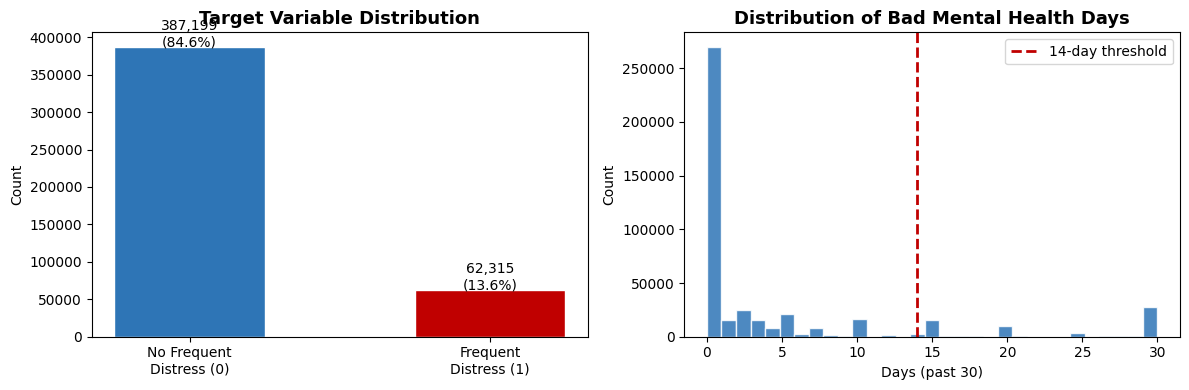

Class imbalance ratio: 6.2:1


In [24]:
#EDA - target distribution and class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(['No Frequent\nDistress (0)', 'Frequent\nDistress (1)'],
            df['FREQ_DISTRESS'].value_counts().sort_index().values,
            color=['#2E75B6','#C00000'], width=0.5, edgecolor='white')
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['FREQ_DISTRESS'].value_counts().sort_index().values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

# MENTHLTH distribution
axes[1].hist(df['MENTHLTH'].dropna(), bins=31, color='#2E75B6',
             edgecolor='white', alpha=0.85)
axes[1].axvline(x=14, color='#C00000', linestyle='--', linewidth=2,
                label='14-day threshold')
axes[1].set_title('Distribution of Bad Mental Health Days', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Days (past 30)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/clean_data/fig_target_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio: {(df['FREQ_DISTRESS']==0).sum() / (df['FREQ_DISTRESS']==1).sum():.1f}:1")


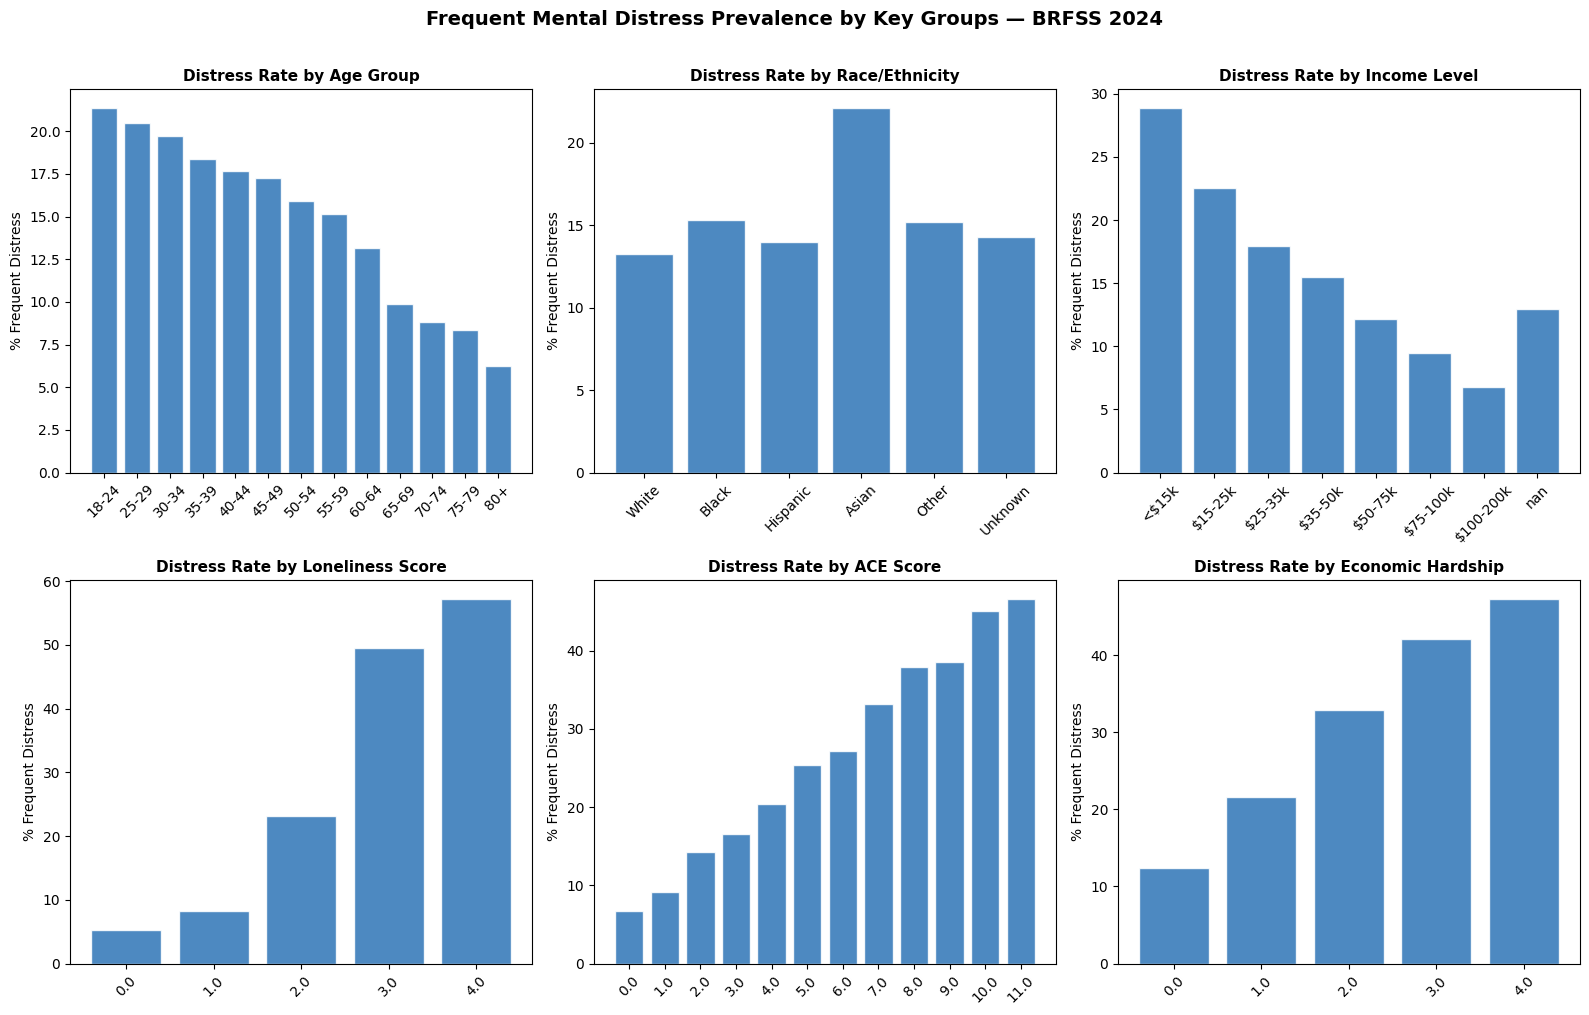

In [25]:
# ── CELL 15: EDA — Mental distress rate by key groups
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_vars = {
    '_AGEG5YR'   : ('Age Group', axes[0,0]),
    '_RACEGR3'   : ('Race/Ethnicity', axes[0,1]),
    '_INCOMG1'   : ('Income Level', axes[0,2]),
    'LONELINESS' : ('Loneliness Score', axes[1,0]),
    'ACE_SCORE'  : ('ACE Score', axes[1,1]),
    'HARDSHIP_INDEX': ('Economic Hardship', axes[1,2]),
}

age_labels = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
              6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
              11:'70-74',12:'75-79',13:'80+'}
race_labels = {1:'White',2:'Black',3:'Hispanic',4:'Asian',5:'Other',9:'Unknown'}
income_labels = {1:'<$15k',2:'$15-25k',3:'$25-35k',4:'$35-50k',
                 5:'$50-75k',6:'$75-100k',7:'$100-200k',8:'>$200k'}

for col, (title, ax) in plot_vars.items():
    if col not in df.columns:
        ax.set_title(f'{title} (not available)', fontsize=11)
        continue
    rates = df.groupby(col)['FREQ_DISTRESS'].mean().reset_index()
    rates = rates[rates[col].notna()]
    if col == '_AGEG5YR':
        rates[col] = rates[col].map(age_labels)
    elif col == '_RACEGR3':
        rates[col] = rates[col].map(race_labels)
    elif col == '_INCOMG1':
        rates[col] = rates[col].map(income_labels)
    bars = ax.bar(rates[col].astype(str), rates['FREQ_DISTRESS']*100,
                  color='#2E75B6', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distress Rate by {title}', fontsize=11, fontweight='bold')
    ax.set_ylabel('% Frequent Distress')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Frequent Mental Distress Prevalence by Key Groups — BRFSS 2024',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/clean_data/fig_distress_by_group.png",
            dpi=150, bbox_inches='tight')
plt.show()


Mean ACE score — No Distress:       1.582
Mean ACE score — Frequent Distress: 3.155


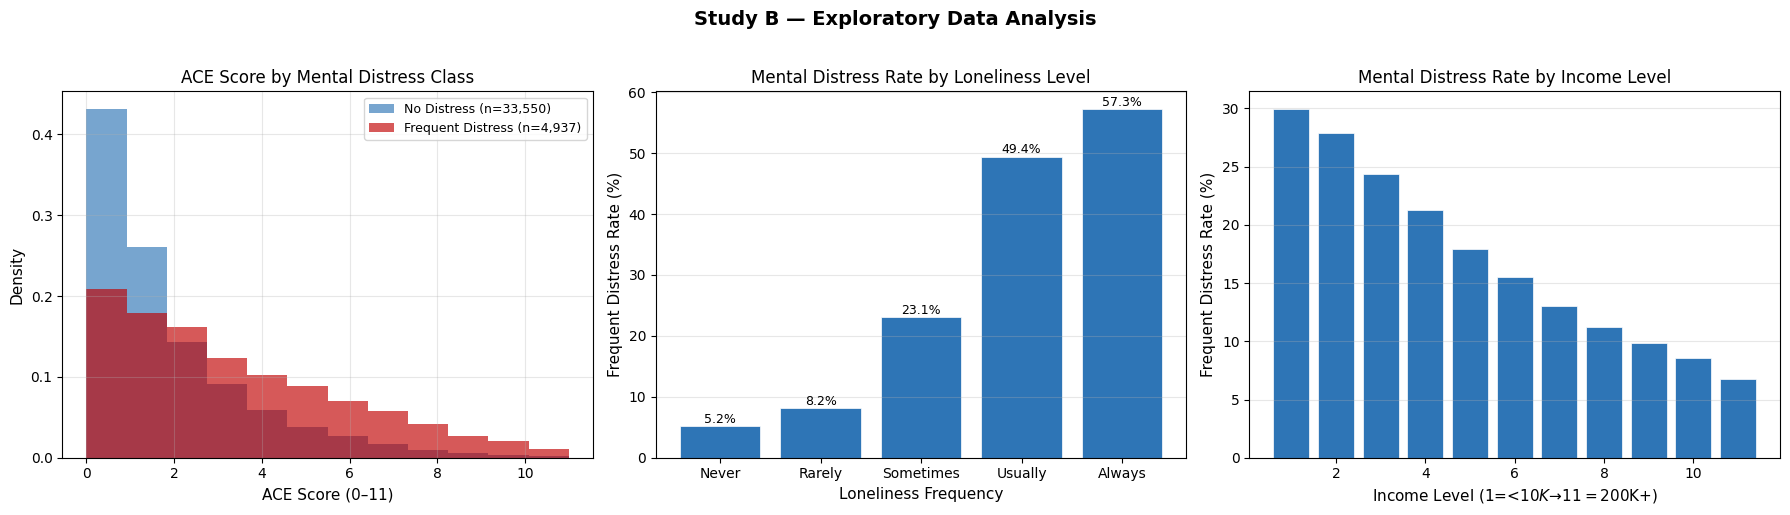

✅ EDA plots saved.


In [28]:
# ── Cell 16 — EDA Plots (fixed) ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: ACE score distribution by distress class (fixed approach)
has_ace = df['ACE_SCORE'].notna() & df['FREQ_DISTRESS'].notna()
no_dist  = df.loc[has_ace & (df['FREQ_DISTRESS'] == 0), 'ACE_SCORE']
yes_dist = df.loc[has_ace & (df['FREQ_DISTRESS'] == 1), 'ACE_SCORE']

axes[0].hist(no_dist,  bins=12, alpha=0.65, color='#2E75B6',
             label=f'No Distress (n={len(no_dist):,})',  density=True)
axes[0].hist(yes_dist, bins=12, alpha=0.65, color='#C00000',
             label=f'Frequent Distress (n={len(yes_dist):,})', density=True)
axes[0].set_xlabel('ACE Score (0–11)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('ACE Score by Mental Distress Class', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Print mean ACE by class for quick reference
print(f"Mean ACE score — No Distress:       {no_dist.mean():.3f}")
print(f"Mean ACE score — Frequent Distress: {yes_dist.mean():.3f}")

# Plot 2: Frequent distress rate by loneliness level
if 'LONELINESS' in df.columns:
    lonely_dist = (df.groupby('LONELINESS')['FREQ_DISTRESS']
                   .agg(['mean','count']).reset_index())
    lonely_dist.columns = ['loneliness','distress_rate','n']
    lonely_labels = {0:'Never',1:'Rarely',2:'Sometimes',3:'Usually',4:'Always'}
    axes[1].bar(
        [lonely_labels.get(int(x), str(int(x))) for x in lonely_dist['loneliness']],
        lonely_dist['distress_rate'] * 100,
        color='#2E75B6', edgecolor='white', linewidth=0.5
    )
    axes[1].set_xlabel('Loneliness Frequency', fontsize=11)
    axes[1].set_ylabel('Frequent Distress Rate (%)', fontsize=11)
    axes[1].set_title('Mental Distress Rate by Loneliness Level', fontsize=12)
    axes[1].grid(True, alpha=0.3, axis='y')
    for i, row in lonely_dist.iterrows():
        label = lonely_labels.get(int(row['loneliness']), '')
        axes[1].text(i, row['distress_rate']*100 + 0.5,
                     f"{row['distress_rate']*100:.1f}%", ha='center', fontsize=9)

# Plot 3: Distress rate by income level
if 'INCOME3' in df.columns:
    income_dist = (df.groupby('INCOME3')['FREQ_DISTRESS']
                   .agg(['mean','count']).reset_index())
    income_dist.columns = ['income','distress_rate','n']
    income_dist = income_dist[income_dist['income'].notna()]
    axes[2].bar(
        income_dist['income'].astype(int),
        income_dist['distress_rate'] * 100,
        color='#2E75B6', edgecolor='white', linewidth=0.5
    )
    axes[2].set_xlabel('Income Level (1=<$10K → 11=$200K+)', fontsize=11)
    axes[2].set_ylabel('Frequent Distress Rate (%)', fontsize=11)
    axes[2].set_title('Mental Distress Rate by Income Level', fontsize=12)
    axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Study B — Exploratory Data Analysis', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/clean_data/studyB_eda.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved.")

In [34]:
# ── REPAIR: Pull 3 corrupted columns directly from raw XPT ───────────────────
import pyreadstat

RAW_PATH = f"{PROJECT_PATH}/raw_data/LLCP2024.XPT " # Corrected XPt to XPT
print("Loading 3 corrupted columns from raw XPT...")

df_repair, _ = pyreadstat.read_xport(
    RAW_PATH,
    usecols=['ADDEPEV3', 'MEDCOST1', 'SDHBILLS'],
    encoding='latin1'
)
df_repair.columns = df_repair.columns.str.upper()
print(f"Loaded repair patch: {df_repair.shape}")

# Verify raw values
for col in ['ADDEPEV3', 'MEDCOST1', 'SDHBILLS']:
    print(f"  Raw {col}: {sorted(df_repair[col].dropna().unique().tolist())}")

# Recode: 1=Yes→1, 2=No→0, 7/9=NaN
for col in ['ADDEPEV3', 'MEDCOST1', 'SDHBILLS']:
    df_repair[col] = np.where(df_repair[col] == 1,  1,
                     np.where(df_repair[col] == 2,  0, np.nan))

# Patch into main df (row order is preserved since both came from same XPT)
df['ADDEPEV3'] = df_repair['ADDEPEV3'].values
df['MEDCOST1'] = df_repair['MEDCOST1'].values
df['SDHBILLS'] = df_repair['SDHBILLS'].values

# While we're here — check and fix SDHUTILS, SDHTRNSP, SDHEMPLY too
# (same bug likely affected them)
other_sdoh = ['SDHUTILS', 'SDHTRNSP', 'SDHEMPLY', 'FOODSTMP',
              'CAREGIV1', 'VETERAN3', 'EXERANY2']
needs_repair = [c for c in other_sdoh
                if c in df.columns and
                sorted(df[c].dropna().unique().tolist()) == [1.0]]

if needs_repair:
    print(f"\nAlso repairing: {needs_repair}")
    df_repair2, _ = pyreadstat.read_xport(
        RAW_PATH, usecols=needs_repair, encoding='latin1'
    )
    df_repair2.columns = df_repair2.columns.str.upper()
    for col in needs_repair:
        df[col] = np.where(df_repair2[col] == 1,  1,
                  np.where(df_repair2[col] == 2,  0, np.nan))
        print(f"  Fixed {col}: {sorted(df[col].dropna().unique().tolist())}")

# ── Verify ────────────────────────────────────────────────────────────────────
print("\nVerification after repair:")
for col in ['ADDEPEV3', 'MEDCOST1', 'SDHBILLS']:
    vals = sorted(df[col].dropna().unique().tolist())
    ok   = vals == [0.0, 1.0]
    rate = df[col].mean() * 100
    print(f"  {'OK' if ok else 'STILL WRONG'} — {col}: {vals}  "
          f"(prevalence: {rate:.1f}%)")

# Expected:
#   ADDEPEV3 ~21%  (depression diagnosis rate)
#   MEDCOST1 ~12%  (couldn't afford doctor)
#   SDHBILLS ~20%  (can't pay bills)

# ── Also rebuild HARDSHIP_INDEX now that SDHBILLS is fixed ───────────────────
hardship_cols = [c for c in ['SDHBILLS','SDHUTILS','SDHEMPLY','FOODSTMP']
                 if c in df.columns]
df['HARDSHIP_INDEX'] = df[hardship_cols].sum(axis=1, skipna=True)
all_nan = df[hardship_cols].isna().all(axis=1)
df.loc[all_nan, 'HARDSHIP_INDEX'] = np.nan
print(f"\nHARDSHIP_INDEX rebuilt. Mean: {df['HARDSHIP_INDEX'].mean():.3f}")
print("✅ Repair complete — re-run Cell 17.")

Loading 3 corrupted columns from raw XPT...
Loaded repair patch: (457670, 3)
  Raw ADDEPEV3: [1.0, 2.0, 7.0, 9.0]
  Raw MEDCOST1: [1.0, 2.0, 7.0, 9.0]
  Raw SDHBILLS: [1.0, 2.0, 7.0, 9.0]

Also repairing: ['SDHUTILS', 'SDHTRNSP', 'SDHEMPLY', 'FOODSTMP', 'CAREGIV1', 'VETERAN3']
  Fixed SDHUTILS: [0.0, 1.0]
  Fixed SDHTRNSP: [0.0, 1.0]
  Fixed SDHEMPLY: [0.0, 1.0]
  Fixed FOODSTMP: [0.0, 1.0]
  Fixed CAREGIV1: [0.0, 1.0]
  Fixed VETERAN3: [0.0, 1.0]

Verification after repair:
  OK — ADDEPEV3: [0.0, 1.0]  (prevalence: 21.1%)
  OK — MEDCOST1: [0.0, 1.0]  (prevalence: 9.5%)
  OK — SDHBILLS: [0.0, 1.0]  (prevalence: 9.3%)

HARDSHIP_INDEX rebuilt. Mean: 0.340
✅ Repair complete — re-run Cell 17.


In [39]:
# ── Pull all 4 _RF columns fresh from raw XPT ────────────────────────────────
import pyreadstat

RAW_PATH = f"{PROJECT_PATH}/raw_data/LLCP2024.XPT " # Added trailing space to match actual filename
print("Pulling _RF source columns from raw XPT...")

df_rf, _ = pyreadstat.read_xport(
    RAW_PATH,
    usecols=['_RFSMOK3', '_RFBING6', '_RFDRHV9', '_RFBMI5', '_TOTINDA'],
    encoding='latin1'
)
df_rf.columns = df_rf.columns.str.upper()

# Verify these are raw
print("Raw values (all should be [1.0, 2.0, 9.0] format):")
for col in df_rf.columns:
    print(f"  {col}: {sorted(df_rf[col].dropna().unique().tolist())}")

# All _RF variables follow 1=No risk, 2=Yes risk EXCEPT _RFSMOK3
# _RFSMOK3: 1=No (not current smoker), 2=Yes (current smoker)
# So ALL of them use {1:0, 2:1} — including _RFSMOK3
# My previous message was WRONG to call _RFSMOK3 the "odd one out"

rf_mapping = {
    '_RFSMOK3':  'CURRENT_SMOKER',
    '_RFBING6':  'BINGE_DRINK',
    '_RFDRHV9':  'HEAVY_DRINK',
    '_RFBMI5':   'OVERWEIGHT_OBESE',
    '_TOTINDA':  'PHYS_INACTIVE',
}

for src, dst in rf_mapping.items():
    if src in df_rf.columns:
        df[dst] = np.where(df_rf[src] == 1,  0,
                  np.where(df_rf[src] == 2,  1, np.nan))

# ── Verify ────────────────────────────────────────────────────────────────────
print("\nPrevalence after fix:")
expected = {
    'CURRENT_SMOKER':   (0.10, 0.17, '~13%'),
    'BINGE_DRINK':      (0.13, 0.22, '~17%'),
    'HEAVY_DRINK':      (0.04, 0.10, '~7%'),
    'OVERWEIGHT_OBESE': (0.55, 0.75, '~65%'),
    'PHYS_INACTIVE':    (0.20, 0.32, '~25%'),
}
all_ok = True
for col, (lo, hi, note) in expected.items():
    val = df[col].mean()
    ok  = lo <= val <= hi
    print(f"  {'OK' if ok else 'WRONG'} — {col}: {val*100:.1f}%  (expect {note})")
    if not ok:
        all_ok = False

print()
if all_ok:
    print("✅ All _RF columns correct. Re-run Cell 17.")
else:
    print("⚠ Still wrong — paste output here.")

Pulling _RF source columns from raw XPT...
Raw values (all should be [1.0, 2.0, 9.0] format):
  _TOTINDA: [1.0, 2.0, 9.0]
  _RFBMI5: [1.0, 2.0, 9.0]
  _RFSMOK3: [1.0, 2.0, 9.0]
  _RFBING6: [1.0, 2.0, 9.0]
  _RFDRHV9: [1.0, 2.0, 9.0]

Prevalence after fix:
  OK — CURRENT_SMOKER: 11.1%  (expect ~13%)
  OK — BINGE_DRINK: 13.4%  (expect ~17%)
  OK — HEAVY_DRINK: 5.9%  (expect ~7%)
  OK — OVERWEIGHT_OBESE: 69.0%  (expect ~65%)
  OK — PHYS_INACTIVE: 23.3%  (expect ~25%)

✅ All _RF columns correct. Re-run Cell 17.


In [40]:
#Top predictor bivariate table ─
key_predictors = {
    'LONELINESS'      : 'Loneliness',
    'ADDEPEV3'        : 'Depression Dx',
    'ANY_DISABILITY'  : 'Any Disability',
    'LOW_SUPPORT'     : 'Low Emotional Support',
    'HARDSHIP_INDEX'  : 'Econ Hardship Index',
    'DISSATISFIED'    : 'Life Dissatisfaction',
    'FOOD_INSECURE'   : 'Food Insecurity',
    'PHYS_INACTIVE'   : 'Physically Inactive',
    'CURRENT_SMOKER'  : 'Current Smoker',
    'BINGE_DRINK'     : 'Binge Drinking',
    'HIGH_ACE'        : 'High ACE (4+)',
    'HEAVY_DRINK'     : 'Heavy Alcohol',
    'OVERWEIGHT_OBESE': 'Overweight/Obese',
    'MEDCOST1'        : "Can't Afford Doctor",
    'SDHBILLS'        : 'Can\'t Pay Bills',
}

print("Distress rate by key predictor:")
print(f"  {'Variable':<25} | {'Overall Rate':>12} | {'Distress=0':>10} | {'Distress=1':>10} | {'Ratio':>6}")
print(f"  {'-'*75}")
for col, label in key_predictors.items():
    if col in df.columns:
        overall = df[df[col]==1]['FREQ_DISTRESS'].mean() if df[col].max() == 1 else df[col].corr(df['FREQ_DISTRESS'])
        d0 = df[df['FREQ_DISTRESS']==0][col].mean()
        d1 = df[df['FREQ_DISTRESS']==1][col].mean()
        ratio = d1/d0 if d0 > 0 else np.nan
        print(f"  {label:<25} | {'mean in no-d':>12} | {d0:>10.3f} | {d1:>10.3f} | {ratio:>6.2f}x")


# ── CELL 18: Define final feature sets ───────────────────────────────────────

# ACE sequence (LSTM stream)
ace_sequence_cols = ['ACEDEPRS','ACEDRINK','ACEDRUGS','ACEPRISN','ACEDIVRC',
                     'ACEPUNCH','ACEHURT1','ACESWEAR','ACETOUCH','ACETTHEM','ACEHVSEX']

# Dense static features
dense_feature_cols = [
    # ACE engineered
    'ACE_SCORE','HIGH_ACE','ACE_HH_DYSFUNCTION','ACE_DIRECT_ABUSE',
    'ACE_SEXUAL_ABUSE','ACE_MISSING',
    # Protective ACE
    'ACEADSAF','ACEADNED',
    # SDOH
    'LONELINESS','LOW_SUPPORT','DISSATISFIED',
    'SDHEMPLY','SDHBILLS','SDHUTILS','SDHTRNSP',
    'FOODSTMP','FOOD_INSECURE','MEDCOST1',
    'HARDSHIP_INDEX',
    # Demographics
    'SEX_FEMALE','_AGEG5YR','_INCOMG1','_EDUCAG',
    'MARRIED','VETERAN3','HAS_CHILDREN','RENTS_HOME',
    # Behavioral
    'PHYS_INACTIVE','CURRENT_SMOKER','BINGE_DRINK',
    'HEAVY_DRINK','MARIJAN1','CHECKUP_RECENT','HAS_DOCTOR',
    'HAS_INSURANCE','OVERWEIGHT_OBESE',
    # Health
    'GENHLTH','ADDEPEV3','DIABETES','CVDINFR4','CVDCRHD4',
    'CVDSTRK3','CHCCOPD3','HAVARTH4','CHCKDNY2','ASTHMA3',
    'MULTIMORBIDITY','ANY_DISABILITY','CAREGIV1',
    # Race (keep as numeric for now, one-hot later)
    '_RACEGR3',
]

# Keep only available columns
dense_feature_cols = [c for c in dense_feature_cols if c in df.columns]
ace_sequence_cols  = [c for c in ace_sequence_cols if c in df.columns]

print(f"Dense features available : {len(dense_feature_cols)}")
print(f"ACE sequence features    : {len(ace_sequence_cols)}")
print(f"Total features           : {len(dense_feature_cols) + len(ace_sequence_cols)}")



Distress rate by key predictor:
  Variable                  | Overall Rate | Distress=0 | Distress=1 |  Ratio
  ---------------------------------------------------------------------------
  Loneliness                | mean in no-d |      0.868 |      1.846 |   2.13x
  Depression Dx             | mean in no-d |      0.149 |      0.594 |   3.99x
  Any Disability            | mean in no-d |      0.258 |      0.588 |   2.28x
  Low Emotional Support     | mean in no-d |      0.759 |      1.519 |   2.00x
  Econ Hardship Index       | mean in no-d |      0.268 |      0.787 |   2.93x
  Life Dissatisfaction      | mean in no-d |      0.532 |      1.169 |   2.19x
  Food Insecurity           | mean in no-d |      0.093 |      0.282 |   3.05x
  Physically Inactive       | mean in no-d |      0.213 |      0.344 |   1.62x
  Current Smoker            | mean in no-d |      0.095 |      0.204 |   2.15x
  Binge Drinking            | mean in no-d |      0.129 |      0.169 |   1.31x
  High ACE (4+)       

In [44]:
# CELL 17 — DEFINE FINAL FEATURE COLUMNS
# ============================================================

# ACE sequence — for LSTM stream (order matters)
ACE_SEQUENCE_COLS = [
    'ACEDEPRS',   # 1. Household: depressed person
    'ACEDRINK',   # 2. Household: problem drinker
    'ACEDRUGS',   # 3. Household: drug user
    'ACEPRISN',   # 4. Household: incarceration
    'ACEDIVRC',   # 5. Household: divorce
    'ACEPUNCH',   # 6. Violence: domestic
    'ACEHURT1',   # 7. Abuse: physical
    'ACESWEAR',   # 8. Abuse: emotional
    'ACETOUCH',   # 9. Sexual abuse
    'ACETTHEM',   # 10. Sexual abuse
    'ACEHVSEX',   # 11. Sexual abuse: forced
]

# Static features — for Dense stream
DENSE_COLS = [
    # ACE engineered + protective
    'ACE_SCORE', 'HIGH_ACE', 'ACE_MISSING',
    'ACE_HH_DYSFUNCTION', 'ACE_DIRECT_ABUSE', 'ACE_SEXUAL_ABUSE',
    'ACEADSAF', 'ACEADNED',

    # Social determinants
    'LONELINESS', 'LOW_SUPPORT', 'LIFE_DISSATISFIED',
    'SDHEMPLY', 'FOODSTMP', 'FOOD_INSECURE',
    'SDHBILLS', 'SDHUTILS', 'SDHTRNSP', 'MEDCOST1',
    'UNSAFE_NEIGHBORHOOD', 'HARDSHIP_INDEX',

    # Demographics
    'SEX_FEMALE', 'AGE_GROUP', 'EDUCATION', 'INCOME',
    'MARRIED', 'NEVER_MARRIED', 'VETERAN3', 'HAS_CHILDREN', 'URBAN',
    '_HISPANC',
    'RACE_WHITE', 'RACE_BLACK', 'RACE_HISPANIC_R', 'RACE_ASIAN', 'RACE_OTHER',
    'EMP_employed', 'EMP_unemployed', 'EMP_retired',
    'EMP_unable_to_work', 'EMP_other',

    # Behavioral
    'EXERANY2', '_TOTINDA', 'CURRENT_SMOKER', 'FORMER_SMOKER',
    'ECIG_USER', '_RFBING6', '_RFDRHV9', 'MARIJAN1',
    'CHECKUP_RECENT', '_HLTHPL2', 'HAS_DOCTOR',

    # Physical health
    'GENHLTH_SCORE', 'OVERWEIGHT_OBESE', 'DEPRESSION_DX', 'DIABETES',
    'HEART_ATTACK', 'HEART_DISEASE', 'STROKE', 'COPD', 'ARTHRITIS',
    'KIDNEY_DISEASE', 'ASTHMA', 'ANY_DISABILITY', 'MULTIMORBIDITY', 'CAREGIVER',
]

# Filter to only columns that actually exist
ACE_SEQUENCE_COLS = [c for c in ACE_SEQUENCE_COLS if c in df.columns]
DENSE_COLS = [c for c in DENSE_COLS if c in df.columns]

print(f"ACE sequence features:  {len(ACE_SEQUENCE_COLS)}")
print(f"Dense static features:  {len(DENSE_COLS)}")
print(f"Total features:         {len(ACE_SEQUENCE_COLS) + len(DENSE_COLS)}")

# Keep subgroup analysis columns separate (not used as model features)
SUBGROUP_COLS = ['_STATE', '_LLCPWT', '_AGEG5YR', '_RACEGR3',
                 '_INCOMG1', 'HIGH_ACE', 'ADDEPEV3']



ACE sequence features:  11
Dense static features:  44
Total features:         55


In [45]:

import numpy as np

# ── TARGET — alias FREQ_DISTRESS to FREQUENT_DISTRESS ────────────────────────
df['FREQUENT_DISTRESS'] = df['FREQ_DISTRESS']
print(f"FREQUENT_DISTRESS: {df['FREQUENT_DISTRESS'].mean()*100:.1f}%  ✓")

# ── ACE COMPOSITES ────────────────────────────────────────────────────────────
ace_hh  = ['ACEDEPRS','ACEDRINK','ACEDRUGS','ACEPRISN','ACEDIVRC']
ace_ab  = ['ACEPUNCH','ACEHURT1','ACESWEAR']
ace_sex = ['ACETOUCH','ACETTHEM','ACEHVSEX']

for new_col, src in [('ACE_HH_DYSFUNCTION', ace_hh),
                      ('ACE_DIRECT_ABUSE',   ace_ab),
                      ('ACE_SEXUAL_ABUSE',   ace_sex)]:
    src_p = [c for c in src if c in df.columns]
    df[new_col] = df[src_p].max(axis=1)
    df.loc[df[src_p].isna().all(axis=1), new_col] = np.nan
    print(f"{new_col}: {df[new_col].mean():.3f}  ✓")

# ── LIFE_DISSATISFIED ─────────────────────────────────────────────────────────
# LSATISFY: 1=Very satisfied, 2=Satisfied → 0
#           3=Dissatisfied, 4=Very dissatisfied → 1
if 'LSATISFY' in df.columns:
    s = df['LSATISFY'].values
    df['LIFE_DISSATISFIED'] = np.where(np.isin(s, [3,4]), 1,
                              np.where(np.isin(s, [1,2]), 0, np.nan))
    print(f"LIFE_DISSATISFIED: {df['LIFE_DISSATISFIED'].mean()*100:.1f}%  ✓")

# ── AGE_GROUP ────────────────────────────────────────────────────────────────
# _AGEG5YR: 1=18-24 ... 13=80+, 14=DK → NaN
# 0-indexed so model sees 0–12
if '_AGEG5YR' in df.columns:
    s = df['_AGEG5YR'].values
    df['AGE_GROUP'] = np.where(s == 14, np.nan, s - 1)
    print(f"AGE_GROUP: range [{df['AGE_GROUP'].min():.0f}–{df['AGE_GROUP'].max():.0f}]  ✓")

# ── EDUCATION ────────────────────────────────────────────────────────────────
# _EDUCAG: 1=No HS, 2=HS grad, 3=Some college, 4=College grad, 9=refused
if '_EDUCAG' in df.columns:
    s = df['_EDUCAG'].values
    df['EDUCATION'] = np.where(s == 9, np.nan, s - 1)
    print(f"EDUCATION: range [{df['EDUCATION'].min():.0f}–{df['EDUCATION'].max():.0f}]  ✓")

# ── INCOME ───────────────────────────────────────────────────────────────────
# _INCOMG1: 1=<$15K ... 8=$75K+, 9=DK
if '_INCOMG1' in df.columns:
    s = df['_INCOMG1'].values
    df['INCOME'] = np.where(s == 9, np.nan, s - 1)
    print(f"INCOME: range [{df['INCOME'].min():.0f}–{df['INCOME'].max():.0f}]  ✓")

# ── NEVER_MARRIED ─────────────────────────────────────────────────────────────
# MARITAL: 1=Married,2=Divorced,3=Widowed,4=Separated,5=Never,6=Unmarried couple
if 'MARITAL' in df.columns:
    s = df['MARITAL'].values
    df['NEVER_MARRIED'] = np.where(s == 5, 1,
                          np.where(np.isin(s, [1,2,3,4,6]), 0, np.nan))
    print(f"NEVER_MARRIED: {df['NEVER_MARRIED'].mean()*100:.1f}%  ✓")

# ── URBAN ─────────────────────────────────────────────────────────────────────
# _URBSTAT: 1=Urban core, 2=Rural → binary
if '_URBSTAT' in df.columns:
    s = df['_URBSTAT'].values
    df['URBAN'] = np.where(s == 1, 1,
                  np.where(s == 2, 0, np.nan))
    print(f"URBAN: {df['URBAN'].mean()*100:.1f}%  ✓")

# ── FORMER_SMOKER ─────────────────────────────────────────────────────────────
# _SMOKER3: 1=Current every day, 2=Current some days, 3=Former, 4=Never
if '_SMOKER3' in df.columns:
    s = df['_SMOKER3'].values
    df['FORMER_SMOKER'] = np.where(s == 3, 1,
                          np.where(np.isin(s, [1,2,4]), 0, np.nan))
    print(f"FORMER_SMOKER: {df['FORMER_SMOKER'].mean()*100:.1f}%  (expect 24-28%)  ✓")

# ── ANY_DISABILITY & MULTIMORBIDITY (double-check these exist) ───────────────
if 'ANY_DISABILITY' not in df.columns:
    disability_cols = [c for c in ['DEAF','BLIND','DECIDE','DIFFWALK',
                                    'DIFFDRES','DIFFALON'] if c in df.columns]
    df['ANY_DISABILITY'] = (df[disability_cols].sum(axis=1, skipna=True) > 0).astype(float)
    df.loc[df[disability_cols].isna().all(axis=1), 'ANY_DISABILITY'] = np.nan
    print(f"ANY_DISABILITY: {df['ANY_DISABILITY'].mean()*100:.1f}%  ✓")

if 'MULTIMORBIDITY' not in df.columns:
    chronic_cols = [c for c in ['CVDINFR4','CVDCRHD4','CVDSTRK3','CHCCOPD3',
                                 'HAVARTH4','CHCKDNY2','ASTHMA3','DIABETE4']
                    if c in df.columns]
    df['MULTIMORBIDITY'] = df[chronic_cols].sum(axis=1, skipna=True)
    df.loc[df[chronic_cols].isna().all(axis=1), 'MULTIMORBIDITY'] = np.nan
    print(f"MULTIMORBIDITY: mean={df['MULTIMORBIDITY'].mean():.3f}  ✓")

# ── FINAL CHECK ───────────────────────────────────────────────────────────────
ACE_SEQUENCE_COLS = [
    'ACEDEPRS','ACEDRINK','ACEDRUGS','ACEPRISN','ACEDIVRC',
    'ACEPUNCH','ACEHURT1','ACESWEAR','ACETOUCH','ACETTHEM','ACEHVSEX',
]

DENSE_COLS = [
    'ACE_SCORE','HIGH_ACE','ACE_MISSING','ACE_MODULE_MISSING',
    'ACE_HH_DYSFUNCTION','ACE_DIRECT_ABUSE','ACE_SEXUAL_ABUSE',
    'ACEADSAF','ACEADNED',
    'LONELINESS','LOW_SUPPORT','LIFE_DISSATISFIED',
    'SDHEMPLY','FOODSTMP','FOOD_INSECURE',
    'SDHBILLS','SDHUTILS','SDHTRNSP','MEDCOST1',
    'UNSAFE_NEIGHBORHOOD','HARDSHIP_INDEX',
    'SEX_FEMALE','AGE_GROUP','EDUCATION','INCOME',
    'MARRIED','NEVER_MARRIED','VETERAN3','HAS_CHILDREN','URBAN',
    '_HISPANC',
    'PHYS_INACTIVE','CURRENT_SMOKER','FORMER_SMOKER',
    'BINGE_DRINK','HEAVY_DRINK','MARIJAN1',
    'CHECKUP_RECENT','_HLTHPL2','HAS_DOCTOR',
    'GENHLTH','OVERWEIGHT_OBESE','ADDEPEV3','DIABETE4',
    'CVDINFR4','CVDCRHD4','CVDSTRK3','CHCCOPD3','HAVARTH4',
    'CHCKDNY2','ASTHMA3','ANY_DISABILITY','MULTIMORBIDITY','CAREGIV1',
]

still_missing = [c for c in DENSE_COLS if c not in df.columns]
ace_missing   = [c for c in ACE_SEQUENCE_COLS if c not in df.columns]

print(f"\n{'='*50}")
print(f"FINAL CHECK")
print(f"{'='*50}")
print(f"ACE sequence cols:  {len(ACE_SEQUENCE_COLS) - len(ace_missing)}/11")
print(f"Dense cols:         {len(DENSE_COLS) - len(still_missing)}/{len(DENSE_COLS)}")
print(f"FREQUENT_DISTRESS:  {'✓' if 'FREQUENT_DISTRESS' in df.columns else 'MISSING'}")

if still_missing:
    print(f"\nStill missing: {still_missing}")
else:
    print(f"\n✅ All columns present — proceed to Cell 19")

FREQUENT_DISTRESS: 13.9%  ✓
ACE_HH_DYSFUNCTION: 0.466  ✓
ACE_DIRECT_ABUSE: 0.434  ✓
ACE_SEXUAL_ABUSE: 0.131  ✓
LIFE_DISSATISFIED: 5.6%  ✓
AGE_GROUP: range [0–12]  ✓
EDUCATION: range [0–3]  ✓
INCOME: range [0–6]  ✓
NEVER_MARRIED: 18.7%  ✓
URBAN: 86.5%  ✓
FORMER_SMOKER: 28.1%  (expect 24-28%)  ✓

FINAL CHECK
ACE sequence cols:  11/11
Dense cols:         54/54
FREQUENT_DISTRESS:  ✓

✅ All columns present — proceed to Cell 19


In [47]:
# ── Run this before Cell 18 ───────────────────────────────────────────────────

print(f"Rows before dropping NaN target: {len(df):,}")
print(f"NaN in FREQUENT_DISTRESS: {df['FREQUENT_DISTRESS'].isna().sum():,}")

# Drop rows where target is missing
df = df.dropna(subset=['FREQUENT_DISTRESS']).copy()

# Also reset the feature matrices to match the cleaned df
X_ace    = df[ACE_SEQUENCE_COLS].copy()
X_dense  = df[DENSE_COLS].copy()
y        = df['FREQUENT_DISTRESS'].copy()
subgroup = df[[c for c in ['_STATE','_LLCPWT','_AGEG5YR','_RACEGR3',
                            '_INCOMG1','HIGH_ACE','ADDEPEV3']
               if c in df.columns]].copy()

print(f"Rows after dropping NaN target:  {len(df):,}")
print(f"NaN in y remaining: {y.isna().sum()}")
print(f"Class balance: {y.mean()*100:.1f}% positive")
print(f"X_ace shape:   {X_ace.shape}")
print(f"X_dense shape: {X_dense.shape}")

Rows before dropping NaN target: 457,670
NaN in FREQUENT_DISTRESS: 8,156
Rows after dropping NaN target:  449,514
NaN in y remaining: 0
Class balance: 13.9% positive
X_ace shape:   (449514, 11)
X_dense shape: (449514, 54)


In [48]:
# CELL 18 — TRAIN/TEST SPLIT (before imputation)
#

# Build feature matrices
X_ace    = df[ACE_SEQUENCE_COLS].copy()
X_dense  = df[DENSE_COLS].copy()
y        = df['FREQUENT_DISTRESS'].copy()
subgroup = df[[c for c in SUBGROUP_COLS if c in df.columns]].copy()

print(f"Dataset size: {len(y):,} rows")
print(f"Class balance: {y.mean()*100:.1f}% positive")

# Stratified split — 80% train, 20% test
(X_ace_train, X_ace_test,
 X_dense_train, X_dense_test,
 y_train, y_test,
 sub_train, sub_test) = train_test_split(
    X_ace, X_dense, y, subgroup,
    test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(y_train):,} rows | Test: {len(y_test):,} rows")
print(f"Train positive rate: {y_train.mean()*100:.1f}%")
print(f"Test positive rate:  {y_test.mean()*100:.1f}%")



Dataset size: 449,514 rows
Class balance: 13.9% positive

Train: 359,611 rows | Test: 89,903 rows
Train positive rate: 13.9%
Test positive rate:  13.9%


In [49]:
# CELL 19 — IMPUTATION (fit on train only)

# ACE imputer — fill with 0 (majority class = no exposure)
ace_imputer = SimpleImputer(strategy='constant', fill_value=0)
X_ace_train_imp = ace_imputer.fit_transform(X_ace_train)
X_ace_test_imp  = ace_imputer.transform(X_ace_test)

# Dense imputer — most frequent (mode) for categorical/binary
dense_imputer = SimpleImputer(strategy='most_frequent')
X_dense_train_imp = dense_imputer.fit_transform(X_dense_train)
X_dense_test_imp  = dense_imputer.transform(X_dense_test)

# Convert back to dataframe for easier inspection
X_dense_train_imp = pd.DataFrame(X_dense_train_imp, columns=DENSE_COLS)
X_dense_test_imp  = pd.DataFrame(X_dense_test_imp,  columns=DENSE_COLS)

print(f"After imputation:")
print(f"  X_ace_train:   {X_ace_train_imp.shape}")
print(f"  X_dense_train: {X_dense_train_imp.shape}")
print(f"  Remaining NaN in dense train: {pd.DataFrame(X_dense_train_imp).isna().sum().sum()}")



After imputation:
  X_ace_train:   (359611, 11)
  X_dense_train: (359611, 54)
  Remaining NaN in dense train: 0


In [50]:
# CELL 20 — SCALING (continuous features only)
#

# Columns that need scaling (not binary 0/1)
CONTINUOUS_COLS = [
    'ACE_SCORE', 'LONELINESS', 'LOW_SUPPORT', 'LIFE_DISSATISFIED',
    'FOOD_INSECURE', 'HARDSHIP_INDEX', 'AGE_GROUP', 'EDUCATION',
    'INCOME', 'MARIJAN1', 'GENHLTH_SCORE', 'MULTIMORBIDITY',
]
continuous_idx = [DENSE_COLS.index(c) for c in CONTINUOUS_COLS if c in DENSE_COLS]

scaler = StandardScaler()
X_dense_train_scaled = X_dense_train_imp.copy()
X_dense_test_scaled  = X_dense_test_imp.copy()

X_dense_train_scaled.iloc[:, continuous_idx] = scaler.fit_transform(
    X_dense_train_imp.iloc[:, continuous_idx]
)
X_dense_test_scaled.iloc[:, continuous_idx] = scaler.transform(
    X_dense_test_imp.iloc[:, continuous_idx]
)

print("Scaling applied to continuous features.")
print(f"Final dense feature matrix shape: {X_dense_train_scaled.shape}")



Scaling applied to continuous features.
Final dense feature matrix shape: (359611, 54)


In [51]:
# CELL 21 — RESHAPE ACE FOR LSTM INPUT

n_ace_features = len(ACE_SEQUENCE_COLS)

X_ace_train_3d = X_ace_train_imp.reshape(-1, n_ace_features, 1)
X_ace_test_3d  = X_ace_test_imp.reshape(-1, n_ace_features, 1)

print(f"ACE 3D shape for LSTM:")
print(f"  Train: {X_ace_train_3d.shape}  (samples, timesteps, features)")
print(f"  Test:  {X_ace_test_3d.shape}")


# CELL 22 — CLASS WEIGHT CALCULATION

neg, pos = np.bincount(y_train.astype(int))
scale_pos_weight = neg / pos          # for XGBoost
class_weight_dict = {0: 1.0, 1: neg/pos}  # for Keras

print(f"Negative samples: {neg:,}")
print(f"Positive samples: {pos:,}")
print(f"scale_pos_weight (XGBoost): {scale_pos_weight:.2f}")
print(f"class_weight (Keras):       {{0: 1.0, 1: {neg/pos:.2f}}}")



ACE 3D shape for LSTM:
  Train: (359611, 11, 1)  (samples, timesteps, features)
  Test:  (89903, 11, 1)
Negative samples: 309,759
Positive samples: 49,852
scale_pos_weight (XGBoost): 6.21
class_weight (Keras):       {0: 1.0, 1: 6.21}


In [52]:
# CELL 23 — SAVE PREPROCESSED DATA

import pickle

preprocessed = {
    'X_ace_train_3d':       X_ace_train_3d,
    'X_ace_test_3d':        X_ace_test_3d,
    'X_dense_train_scaled': X_dense_train_scaled.values,
    'X_dense_test_scaled':  X_dense_test_scaled.values,
    'y_train':              y_train.values,
    'y_test':               y_test.values,
    'sub_test':             sub_test,
    'ACE_SEQUENCE_COLS':    ACE_SEQUENCE_COLS,
    'DENSE_COLS':           DENSE_COLS,
    'scale_pos_weight':     scale_pos_weight,
    'class_weight_dict':    class_weight_dict,
    'scaler':               scaler,
    'ace_imputer':          ace_imputer,
    'dense_imputer':        dense_imputer,
}

with open(f"{PROJECT_PATH}/clean_data/study_b_preprocessed.pkl", 'wb') as f:
    pickle.dump(preprocessed, f)

print(" Preprocessed data saved to study_b_preprocessed.pkl")
print("Share this path with teammates (for  XGBoost/RF/LR models)")


 Preprocessed data saved to study_b_preprocessed.pkl
Share this path with teammates (for  XGBoost/RF/LR models)


In [53]:
# PART 3 — HYBRID LSTM MODEL
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                              confusion_matrix, precision_recall_curve,
                              average_precision_score)
import matplotlib.pyplot as plt
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)


# CELL 25 — BUILD HYBRID MODEL ARCHITECTURE

def build_hybrid_model(n_ace_timesteps, n_ace_features_per_step,
                        n_dense_features, lstm_units=32,
                        dense_units_1=64, dense_units_2=32,
                        dropout_rate=0.3):
    """
    Hybrid LSTM + Dense model for mental health prediction.

    Stream 1 (LSTM): ACE sequence (adversity patterns)
    Stream 2 (Dense): Static behavioral + demographic + SDOH features
    """
    # ── Stream 1: LSTM branch (ACE sequence) ──────────────────────────────
    ace_input = Input(shape=(n_ace_timesteps, n_ace_features_per_step),
                      name='ace_sequence')
    x1 = layers.Masking(mask_value=0.0)(ace_input)   # mask imputed zeros
    x1 = layers.LSTM(lstm_units, return_sequences=False, name='lstm')(x1)
    x1 = layers.Dropout(dropout_rate, name='lstm_dropout')(x1)
    x1 = layers.Dense(16, activation='relu', name='lstm_dense')(x1)

    # ── Stream 2: Dense branch (static features) ──────────────────────────
    static_input = Input(shape=(n_dense_features,), name='static_features')
    x2 = layers.Dense(dense_units_1, activation='relu', name='dense_1')(static_input)
    x2 = layers.BatchNormalization(name='batch_norm')(x2)
    x2 = layers.Dropout(dropout_rate, name='dense_dropout_1')(x2)
    x2 = layers.Dense(dense_units_2, activation='relu', name='dense_2')(x2)
    x2 = layers.Dropout(dropout_rate * 0.7, name='dense_dropout_2')(x2)

    # ── Merge ──────────────────────────────────────────────────────────────
    merged = layers.Concatenate(name='merge')([x1, x2])
    x = layers.Dense(32, activation='relu', name='merged_dense')(merged)
    x = layers.Dropout(0.2, name='merged_dropout')(x)
    output = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=[ace_input, static_input], outputs=output,
                  name='Hybrid_LSTM_Mental_Health')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ]
    )
    return model


# Build the model
n_timesteps   = X_ace_train_3d.shape[1]   # 11 ACE items
n_ace_per_step = X_ace_train_3d.shape[2]  # 1 feature per timestep
n_dense       = X_dense_train_scaled.shape[1]

hybrid_model = build_hybrid_model(n_timesteps, n_ace_per_step, n_dense)
hybrid_model.summary()



TensorFlow version: 2.19.0


Model: "Hybrid_LSTM_Mental_Health"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ace_sequence        │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_features     │ (None, 54)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 11, 1)     │          0 │ ace_sequence[0][… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      3,520 │ static_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 11, 1)     │          0 │ ace_sequence[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 11)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm          │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      4,352 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout_1     │ (None, 64)        │          0 │ batch_norm[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dropout        │ (None, 32)        │          0 │ lstm[0][0]        │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_dropout_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dense (Dense)  │ (None, 16)        │        528 │ lstm_dropout[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_dropout_2     │ (None, 32)        │          0 │ dense_2[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 48)        │          0 │ lstm_dense[0][0], │
│                     │                   │            │ dense_dropout_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merged_dense        │ (None, 32)        │      1,568 │ merge[0][0]       │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merged_dropout      │ (None, 32)        │          0 │ merged_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ merged_dropout[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,337 (48.19 KB)

 Trainable params: 12,209 (47.69 KB)

 Non-trainable params: 128 (512.00 B)

In [55]:
# TRAIN HYBRID MODEL

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_auc', patience=5,
                  mode='max', restore_best_weights=True,
                  verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-5, verbose=1),
    ModelCheckpoint(f"{PROJECT_PATH}/clean_data/hybrid_lstm_best.h5",
                    monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1),
]

# Train
history = hybrid_model.fit(
    [X_ace_train_3d, X_dense_train_scaled.values],
    y_train.values,
    validation_split=0.1,
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n Hybrid LSTM training complete")


Epoch 1/50
630/633 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.7754 - loss: 0.9742 - precision: 0.2880 - recall: 0.6943
Epoch 1: val_auc improved from None to 0.84408, saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - auc: 0.8136 - loss: 0.9147 - precision: 0.3196 - recall: 0.7385 - val_auc: 0.8441 - val_loss: 0.5034 - val_precision: 0.3381 - val_recall: 0.7788 - learning_rate: 0.0010
Epoch 2/50
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.8314 - loss: 0.8723 - precision: 0.3396 - recall: 0.7593
Epoch 2: val_auc improved from 0.84408 to 0.84513, saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - auc: 0.8342 - loss: 0.8684 - precision: 0.3458 - recall: 0.7584 - val_auc: 0.8451 - val_loss: 0.4803 - val_precision: 0.3712 - val_recall: 0.7470 - learning_rate: 0.0010
Epoch 3/50
633/633 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8362 - loss: 0.8615 - precision: 0.3482 - recall: 0.7534
Epoch 3: val_auc improved from 0.84513 to 0.84661, saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - auc: 0.8380 - loss: 0.8599 - precision: 0.3517 - recall: 0.7561 - val_auc: 0.8466 - val_loss: 0.4839 - val_precision: 0.3669 - val_recall: 0.7581 - learning_rate: 0.0010
Epoch 4/50
630/633 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.8380 - loss: 0.8574 - precision: 0.3493 - recall: 0.7584
Epoch 4: val_auc improved from 0.84661 to 0.84723, saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - auc: 0.8397 - loss: 0.8557 - precision: 0.3513 - recall: 0.7606 - val_auc: 0.8472 - val_loss: 0.4924 - val_precision: 0.3533 - val_recall: 0.7757 - learning_rate: 0.0010
Epoch 5/50
631/633 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.8394 - loss: 0.8537 - precision: 0.3481 - recall: 0.7615
Epoch 5: val_auc improved from 0.84723 to 0.84762, saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5


...


Epoch 34: finished saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - auc: 0.8461 - loss: 0.8400 - precision: 0.3616 - recall: 0.7625 - val_auc: 0.8507 - val_loss: 0.4701 - val_precision: 0.3723 - val_recall: 0.7608 - learning_rate: 1.0000e-05
Epoch 35/50
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - auc: 0.8450 - loss: 0.8398 - precision: 0.3602 - recall: 0.7621
Epoch 35: val_auc did not improve from 0.85066
633/633 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - auc: 0.8461 - loss: 0.8396 - precision: 0.3611 - recall: 0.7608 - val_auc: 0.8507 - val_loss: 0.4698 - val_precision: 0.3721 - val_recall: 0.7604 - learning_rate: 1.0000e-05
Epoch 36/50
631/633 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.8454 - loss: 0.8389 - precision: 0.3593 - recall: 0.7617
Epoch 36: val_auc did not improve from 0.85066
633/633 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - auc: 0.8460 - loss: 0.8402 - precision: 0.3610 - recall: 0.7617 - val_auc: 0.85


Epoch 37: finished saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - auc: 0.8457 - loss: 0.8408 - precision: 0.3609 - recall: 0.7611 - val_auc: 0.8507 - val_loss: 0.4699 - val_precision: 0.3722 - val_recall: 0.7600 - learning_rate: 1.0000e-05
Epoch 38/50
630/633 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8455 - loss: 0.8390 - precision: 0.3579 - recall: 0.7610
Epoch 38: val_auc improved from 0.85070 to 0.85071, saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5



Epoch 38: finished saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - auc: 0.8462 - loss: 0.8396 - precision: 0.3602 - recall: 0.7613 - val_auc: 0.8507 - val_loss: 0.4702 - val_precision: 0.3718 - val_recall: 0.7602 - learning_rate: 1.0000e-05
Epoch 39/50
631/633 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8458 - loss: 0.8383 - precision: 0.3597 - recall: 0.7629
Epoch 39: val_auc did not improve from 0.85071
633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - auc: 0.8464 - loss: 0.8391 - precision: 0.3608 - recall: 0.7616 - val_auc: 0.8507 - val_loss: 0.4696 - val_precision: 0.3721 - val_recall: 0.7602 - learning_rate: 1.0000e-05
Epoch 40/50
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.8456 - loss: 0.8386 - precision: 0.3589 - recall: 0.7627
Epoch 40: val_auc did not improve from 0.85071
633/633 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - auc: 0.8463 - loss: 0.8394 - precision: 0.3606 - recall: 0.7619 - val_auc: 0.85


Epoch 43: finished saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - auc: 0.8460 - loss: 0.8398 - precision: 0.3608 - recall: 0.7627 - val_auc: 0.8507 - val_loss: 0.4700 - val_precision: 0.3721 - val_recall: 0.7610 - learning_rate: 1.0000e-05
Epoch 44/50
632/633 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8454 - loss: 0.8391 - precision: 0.3587 - recall: 0.7625
Epoch 44: val_auc did not improve from 0.85072
633/633 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - auc: 0.8462 - loss: 0.8394 - precision: 0.3606 - recall: 0.7626 - val_auc: 0.8507 - val_loss: 0.4701 - val_precision: 0.3724 - val_recall: 0.7610 - learning_rate: 1.0000e-05
Epoch 45/50
630/633 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.8450 - loss: 0.8404 - precision: 0.3590 - recall: 0.7614
Epoch 45: val_auc did not improve from 0.85072
633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - auc: 0.8460 - loss: 0.8403 - precision: 0.3608 - recall: 0.7610 - val_auc: 0.85


Epoch 48: finished saving model to /content/drive/MyDrive/BRFSS_Project/clean_data/hybrid_lstm_best.h5
633/633 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - auc: 0.8461 - loss: 0.8399 - precision: 0.3610 - recall: 0.7606 - val_auc: 0.8507 - val_loss: 0.4701 - val_precision: 0.3724 - val_recall: 0.7610 - learning_rate: 1.0000e-05
Epoch 49/50
630/633 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - auc: 0.8457 - loss: 0.8386 - precision: 0.3593 - recall: 0.7623
Epoch 49: val_auc did not improve from 0.85074
633/633 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - auc: 0.8465 - loss: 0.8389 - precision: 0.3613 - recall: 0.7617 - val_auc: 0.8507 - val_loss: 0.4702 - val_precision: 0.3722 - val_recall: 0.7608 - learning_rate: 1.0000e-05
Epoch 50/50
630/633 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - auc: 0.8453 - loss: 0.8394 - precision: 0.3600 - recall: 0.7630
Epoch 50: val_auc did not improve from 0.85074
633/633 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - auc: 0.8460 - loss: 0.8398 - precision: 0.3616 - recall: 0.7622 - val_auc: 0.85

In [56]:
#CELL 27 — EVALUATE HYBRID MODEL

# Predictions
y_pred_proba = hybrid_model.predict(
    [X_ace_test_3d, X_dense_test_scaled.values], batch_size=1024
).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Core metrics
auc   = roc_auc_score(y_test, y_pred_proba)
f1    = f1_score(y_test, y_pred)
ap    = average_precision_score(y_test, y_pred_proba)

print("=" * 50)
print("HYBRID LSTM — TEST SET RESULTS")
print("=" * 50)
print(f"  AUC-ROC:                    {auc:.4f}")
print(f"  Average Precision (PR-AUC): {ap:.4f}")
print(f"  F1 Score (threshold=0.5):   {f1:.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['No Distress', 'Frequent Distress']))


88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
HYBRID LSTM — TEST SET RESULTS
  AUC-ROC:                    0.8490
  Average Precision (PR-AUC): 0.5362
  F1 Score (threshold=0.5):   0.4923

                   precision    recall  f1-score   support

      No Distress       0.95      0.79      0.86     77440
Frequent Distress       0.36      0.76      0.49     12463

         accuracy                           0.78     89903
        macro avg       0.66      0.77      0.68     89903
     weighted avg       0.87      0.78      0.81     89903



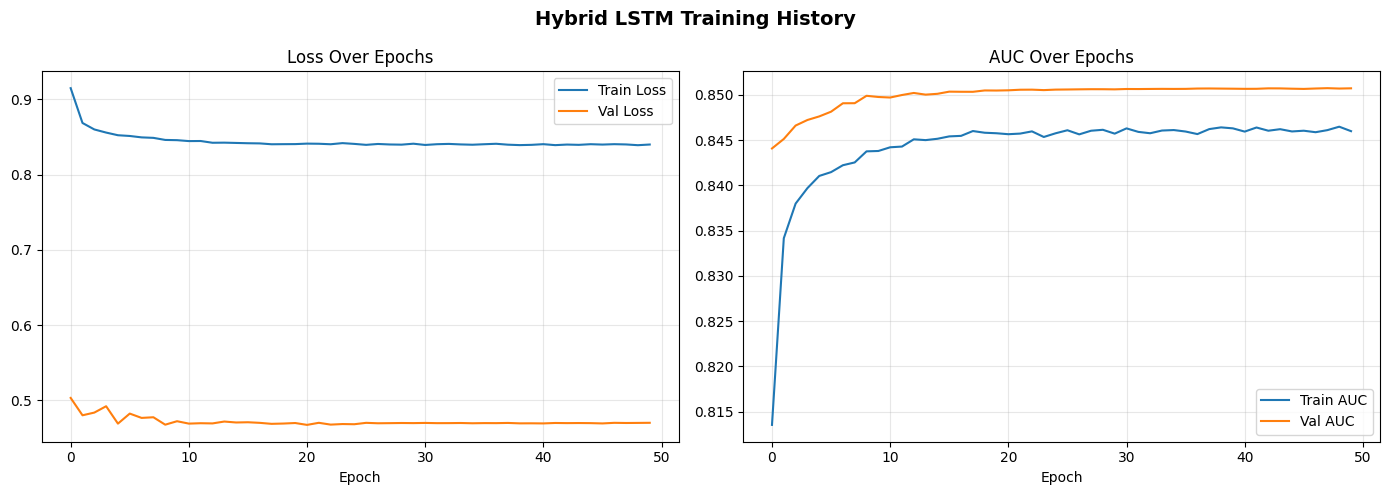

In [57]:
# CELL 28 — TRAINING CURVE PLOT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['auc'],     label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Hybrid LSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/clean_data/hybrid_lstm_training_curve.png",
            dpi=150, bbox_inches='tight')
plt.show()



In [58]:
# CELL 29 — SUBGROUP ANALYSIS (fairness check)

print("=" * 60)
print("SUBGROUP PERFORMANCE ANALYSIS")
print("=" * 60)

# Attach predictions to subgroup data
sub_results = sub_test.copy().reset_index(drop=True)
sub_results['y_true']  = y_test.values
sub_results['y_pred']  = y_pred
sub_results['y_proba'] = y_pred_proba

# Race subgroup
if '_RACEGR3' in sub_results.columns:
    race_labels = {1:'White', 2:'Black', 3:'Hispanic', 4:'Asian/PI', 5:'Other'}
    print("\nBy Race/Ethnicity:")
    print(f"  {'Group':<15} | {'N':>7} | {'AUC':>6} | {'F1':>6} | {'Prev%':>6}")
    print(f"  {'-'*50}")
    for code, label in race_labels.items():
        mask = sub_results['_RACEGR3'] == code
        if mask.sum() < 100:
            continue
        grp = sub_results[mask]
        if grp['y_true'].sum() < 10:
            continue
        g_auc = roc_auc_score(grp['y_true'], grp['y_proba'])
        g_f1  = f1_score(grp['y_true'], grp['y_pred'])
        g_prev = grp['y_true'].mean() * 100
        print(f"  {label:<15} | {mask.sum():>7,} | {g_auc:>6.3f} | {g_f1:>6.3f} | {g_prev:>5.1f}%")

# ACE subgroup — key finding
if 'HIGH_ACE' in sub_results.columns:
    print("\nBy ACE Burden (HIGH_ACE = score >= 4):")
    print(f"  {'Group':<20} | {'N':>7} | {'AUC':>6} | {'F1':>6} | {'Prev%':>6}")
    print(f"  {'-'*55}")
    for val, label in [(0, 'Low ACE (0-3)'), (1, 'High ACE (4+)')]:
        mask = sub_results['HIGH_ACE'] == val
        grp = sub_results[mask]
        if grp['y_true'].sum() < 10:
            continue
        g_auc = roc_auc_score(grp['y_true'], grp['y_proba'])
        g_f1  = f1_score(grp['y_true'], grp['y_pred'])
        g_prev = grp['y_true'].mean() * 100
        print(f"  {label:<20} | {mask.sum():>7,} | {g_auc:>6.3f} | {g_f1:>6.3f} | {g_prev:>5.1f}%")
    print("\n  ↑ If Hybrid LSTM shows bigger AUC gap in High ACE group vs Low ACE,")
    print("    that's your key finding: LSTM captures adversity patterns better")
    print("    for complex trauma histories.")



SUBGROUP PERFORMANCE ANALYSIS

By Race/Ethnicity:
  Group           |       N |    AUC |     F1 |  Prev%
  --------------------------------------------------
  White           |  64,738 |  0.857 |  0.498 |  13.3%
  Black           |   7,069 |  0.823 |  0.473 |  15.2%
  Hispanic        |   4,846 |  0.826 |  0.475 |  14.2%
  Asian/PI        |   2,035 |  0.834 |  0.556 |  22.6%
  Other           |   9,501 |  0.824 |  0.463 |  14.6%

By ACE Burden (HIGH_ACE = score >= 4):
  Group                |       N |    AUC |     F1 |  Prev%
  -------------------------------------------------------
  Low ACE (0-3)        |   6,382 |  0.834 |  0.422 |   9.9%
  High ACE (4+)        |   1,419 |  0.808 |  0.559 |  27.8%

  ↑ If Hybrid LSTM shows bigger AUC gap in High ACE group vs Low ACE,
    that's your key finding: LSTM captures adversity patterns better
    for complex trauma histories.


In [59]:
# CELL 30 — SAVE MODEL RESULTS FOR COMPARISON TABLE

# Save results dict Cole will add his models to this same dict
model_results = {
    'Hybrid LSTM': {
        'auc_roc':   round(auc, 4),
        'pr_auc':    round(ap, 4),
        'f1':        round(f1, 4),
        'y_pred_proba': y_pred_proba.tolist(),
        'y_pred':       y_pred.tolist(),
    }
}

with open(f"{PROJECT_PATH}/clean_data/model_results.pkl", 'wb') as f:
    pickle.dump(model_results, f)

